# Studi Klasifikasi Machine Failure — `dataset.csv`

Sembilan tahap studi klasifikasi kegagalan mesin pada `dataset.csv`:
empat pembacaan sensor dan satu label `Machine failure`.

**Aturan yang dipegang di seluruh notebook:**

1. `random_state=42` di setiap komponen stokastik.
2. Fitur hanya empat sensor mentah dan turunan fisis darinya. Dataset ini
   tidak memuat torsi, `Type`, maupun label mode kegagalan.
3. Semua scaling dan resampling di-fit **di dalam** fold lewat
   `imblearn.pipeline.Pipeline`, bukan pada seluruh dataset.
4. **PR-AUC dan recall kelas minoritas** adalah metrik keputusan.
   Accuracy dan ROC-AUC dilaporkan tapi tidak dipakai memilih model.
5. Test set dikunci di TAHAP 4 dan dibuka satu kali di TAHAP 7.

Keluaran: `model_klasifikasi_failure.pkl`.


In [1]:
# ============================================================================
# SETUP — konstanta, palet visual, helper
# ============================================================================
import json
import os
import platform
import sys
import time
import warnings
from datetime import date

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
warnings.filterwarnings("ignore")

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling.base import BaseOverSampler
from imblearn.pipeline import Pipeline
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import loguniform, randint, uniform
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, f1_score, make_scorer,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_val_predict, cross_validate,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

RS = 42
CSV = "dataset.csv"

TARGET = "Machine failure"

RAW_FEATURES = ["Air temperature K", "Process temperature K",
                "Rotational speed rpm", "Tool wear min"]
SHORT = {"Air temperature K": "air_temp_K",
         "Process temperature K": "proc_temp_K",
         "Rotational speed rpm": "rpm",
         "Tool wear min": "tool_wear_min"}
ENG_FEATURES = ["Temp_diff", "Temp_ratio", "Wear_x_rpm",
                "Cooling_margin_rate", "Thermal_wear_load"]
FEATURES = [SHORT[c] for c in RAW_FEATURES] + ENG_FEATURES


def sec(judul):
    print("\n" + "=" * 78)
    print(judul)
    print("=" * 78)


print(f"python {sys.version.split()[0]} | numpy {np.__version__} | "
      f"pandas {pd.__version__} | sklearn {__import__('sklearn').__version__}")
print(f"imblearn {__import__('imblearn').__version__} | "
      f"xgboost {__import__('xgboost').__version__} | shap {shap.__version__}")

python 3.12.5 | numpy 2.4.6 | pandas 2.3.3 | sklearn 1.8.0
imblearn 0.14.2 | xgboost 3.0.5 | shap 0.52.0


In [2]:
# ----------------------------------------------------------------------------
# Palet visual.
#
# Palet kategorikal sudah divalidasi (light surface #fcfcfb, semua pasangan):
# worst CVD dE 9.2 (deutan), worst normal-vision dE 16.3 -> lolos semua gate.
# Slot kuning bawaan diganti violet karena pasangan kuning-oranye gagal
# normal-vision floor (dE 13.7) padahal kurva ROC/PR menaruh empat seri
# sekaligus di satu bidang.
# ----------------------------------------------------------------------------
SERI = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]  # blue, orange, aqua, violet
# Slot ke-5 (yellow) khusus grafik strategi. Ia hanya lolos gate pada pairlist
# ADJACENT — yang memang berlaku untuk grouped bar chart, di mana urutan bar
# tetap dan tiap bar dipisah gap 2px. Kuning juga di bawah 3:1 terhadap surface,
# jadi figure-nya wajib berlegend dan angkanya tersedia sebagai CSV.
SERI_STRATEGI = SERI + ["#eda100"]

NAMA_MODEL = ["LogisticRegression", "RandomForest", "XGBoost", "FNN"]
NAMA_STRATEGI = ["baseline", "class_weight", "SMOTE", "SMOTETomek", "Jitter"]

WARNA_MODEL = dict(zip(NAMA_MODEL, SERI))
WARNA_STRATEGI = dict(zip(NAMA_STRATEGI, SERI_STRATEGI))
WARNA_KELAS = {0: SERI[0], 1: SERI[1]}

SURFACE, INK, INK_2, MUTED, GRID, AXIS = ("#fcfcfb", "#0b0b0b", "#52514e",
                                          "#898781", "#e1e0d9", "#c3c2b7")

CMAP_SEQ = LinearSegmentedColormap.from_list(
    "biru_seq", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#256abf",
                 "#184f95", "#0d366b"])
CMAP_DIV = LinearSegmentedColormap.from_list(
    "biru_merah_div", ["#0d366b", "#256abf", "#5598e7", "#9ec5f4", "#f0efec",
                       "#f0a3a2", "#e34948", "#c02c2b", "#8f1f1e"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.labelcolor": INK_2, "axes.labelsize": 10, "axes.edgecolor": AXIS,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK_2,
    "axes.prop_cycle": mpl.cycler(color=SERI),
})
print("palet & gaya figure siap")

palet & gaya figure siap


---
## TAHAP 1 — Pemuatan Data dan EDA

In [4]:
raw = pd.read_csv(CSV, index_col=0)

sec("1.1  Dimensi dan tipe data")
print(f"Dimensi : {raw.shape[0]} baris x {raw.shape[1]} kolom")
print()
print(pd.DataFrame({"dtype": raw.dtypes.astype(str),
                    "n_unik": raw.nunique(),
                    "contoh": raw.iloc[0]}).to_string())


1.1  Dimensi dan tipe data
Dimensi : 9922 baris x 5 kolom

                         dtype  n_unik  contoh
Air temperature K      float64      93   298.1
Process temperature K  float64      82   308.6
Rotational speed rpm     int64     938  1551.0
Tool wear min            int64     245     0.0
Machine failure          int64       2     0.0


In [5]:
sec("1.2  Statistik deskriptif")
desc = raw.describe().T
print(desc.to_string(float_format=lambda v: f"{v:10.3f}"))



1.2  Statistik deskriptif
                           count       mean        std        min        25%        50%        75%        max
Air temperature K       9922.000    300.006      2.001    295.300    298.300    300.100    301.500    304.500
Process temperature K   9922.000    310.005      1.483    305.700    308.800    310.100    311.100    313.800
Rotational speed rpm    9922.000   1540.227    179.159   1168.000   1425.000   1505.000   1613.000   2886.000
Tool wear min           9922.000    107.163     63.265      0.000     52.000    107.000    161.000    253.000
Machine failure         9922.000      0.026      0.160      0.000      0.000      0.000      0.000      1.000


In [6]:
sec("1.3  Missing value dan duplikat")
n_miss = raw.isna().sum()
print(f"Total missing value seluruh tabel : {int(n_miss.sum())}")
print(f"Kolom dengan missing value        : {list(n_miss[n_miss > 0].index) or 'tidak ada'}")
print(f"Baris duplikat penuh              : {int(raw.duplicated().sum())}")
print()
if n_miss.sum() == 0:
    print("PERNYATAAN EKSPLISIT:")
    print("  Dataset ini TIDAK memiliki satu pun missing value.")
    print("  Karena itu tidak ada imputasi yang dijalankan di studi ini.")
    print("  Menjalankan imputer di sini hanya akan jadi langkah kosmetik")
    print("  yang menambah kompleksitas pipeline tanpa mengubah apa pun.")


1.3  Missing value dan duplikat
Total missing value seluruh tabel : 0
Kolom dengan missing value        : tidak ada
Baris duplikat penuh              : 1

PERNYATAAN EKSPLISIT:
  Dataset ini TIDAK memiliki satu pun missing value.
  Karena itu tidak ada imputasi yang dijalankan di studi ini.
  Menjalankan imputer di sini hanya akan jadi langkah kosmetik
  yang menambah kompleksitas pipeline tanpa mengubah apa pun.


In [7]:
sec("1.4  Distribusi kelas target dan imbalance ratio")
vc = raw[TARGET].value_counts().sort_index()
n = len(raw)
n_neg, n_pos = int(vc[0]), int(vc[1])
ir = n_neg / n_pos
print(f"Kelas 0 (normal) : {n_neg:5d}  ({n_neg / n:6.2%})")
print(f"Kelas 1 (gagal)  : {n_pos:5d}  ({n_pos / n:6.2%})")
print()
print(f"IMBALANCE RATIO  : {ir:.2f} : 1   (1 kegagalan setiap {ir:.1f} unit normal)")
print(f"Baseline majority-class accuracy = {n_neg / n:.4%}")
print("  -> model yang selalu menebak 'normal' sudah dapat accuracy segitu")
print("     tanpa mendeteksi satu pun kegagalan.")
print()
print("Dataset ini tidak memuat kolom mode kegagalan, jadi yang tersedia hanya")
print("label biner Machine failure — tanpa rincian mekanisme di baliknya.")


1.4  Distribusi kelas target dan imbalance ratio
Kelas 0 (normal) :  9661  (97.37%)
Kelas 1 (gagal)  :   261  ( 2.63%)

IMBALANCE RATIO  : 37.02 : 1   (1 kegagalan setiap 37.0 unit normal)
Baseline majority-class accuracy = 97.3695%
  -> model yang selalu menebak 'normal' sudah dapat accuracy segitu
     tanpa mendeteksi satu pun kegagalan.

Dataset ini tidak memuat kolom mode kegagalan, jadi yang tersedia hanya
label biner Machine failure — tanpa rincian mekanisme di baliknya.



1.5  Distribusi tiap fitur numerik per kelas


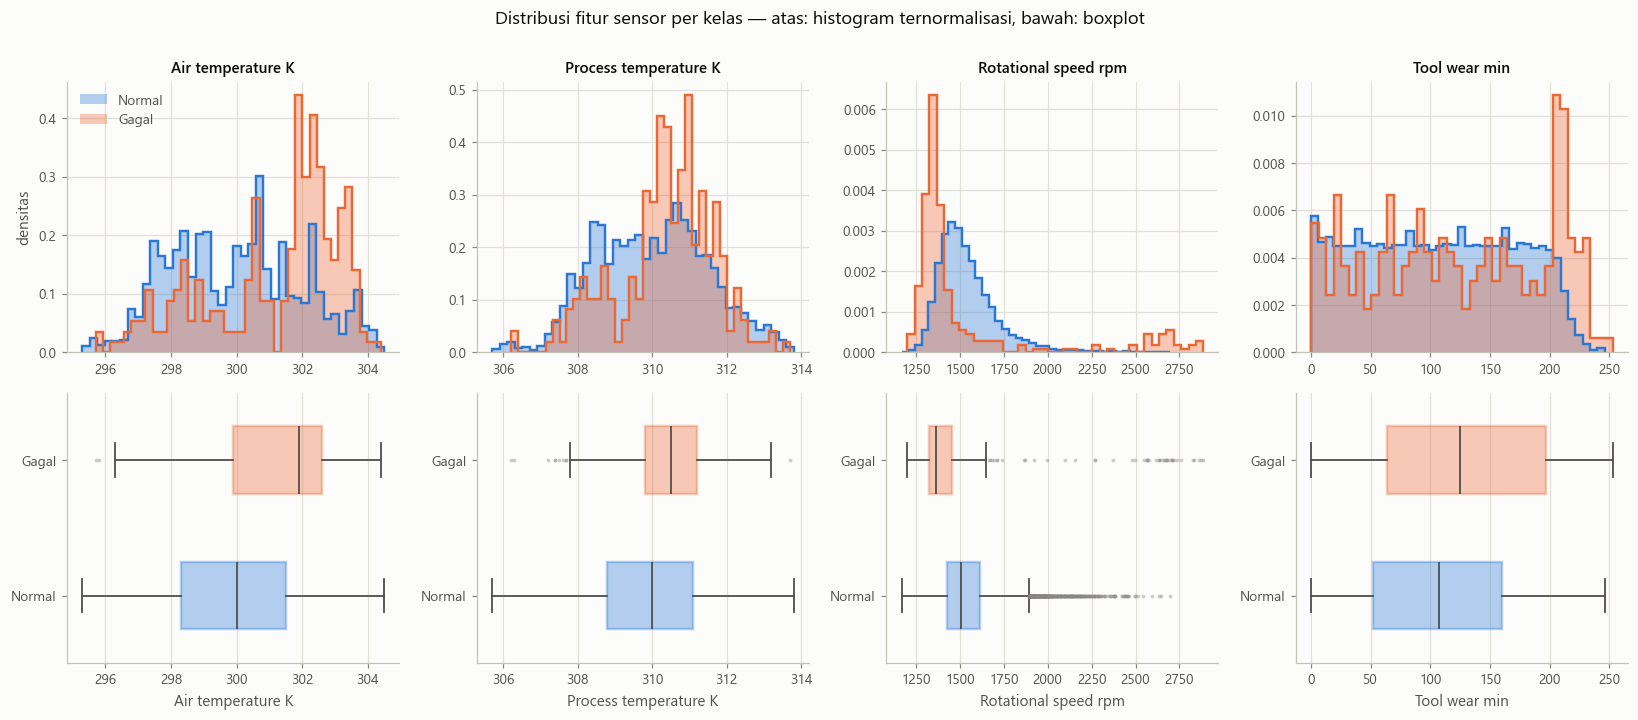

In [8]:
sec("1.5  Distribusi tiap fitur numerik per kelas")
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for j, kol in enumerate(RAW_FEATURES):
    ax = axes[0, j]
    for kelas, label in [(0, "Normal"), (1, "Gagal")]:
        sub = raw.loc[raw[TARGET] == kelas, kol]
        ax.hist(sub, bins=40, density=True, histtype="stepfilled",
                color=WARNA_KELAS[kelas], alpha=0.35, label=label)
        ax.hist(sub, bins=40, density=True, histtype="step",
                color=WARNA_KELAS[kelas], linewidth=1.6)
    ax.set_title(kol.replace(" [", "\n["), fontsize=10)
    ax.set_ylabel("densitas" if j == 0 else "")
    if j == 0:
        ax.legend(loc="upper left")

    ax2 = axes[1, j]
    data = [raw.loc[raw[TARGET] == k, kol].values for k in (0, 1)]
    bp = ax2.boxplot(data, vert=False, widths=0.5, patch_artist=True,
                     tick_labels=["Normal", "Gagal"], showfliers=True,
                     flierprops=dict(marker="o", markersize=2.5,
                                     markerfacecolor=MUTED,
                                     markeredgecolor="none", alpha=0.4))
    for patch, k in zip(bp["boxes"], (0, 1)):
        patch.set_facecolor(WARNA_KELAS[k])
        patch.set_alpha(0.35)
        patch.set_edgecolor(WARNA_KELAS[k])
        patch.set_linewidth(1.6)
    for elem in ("whiskers", "caps", "medians"):
        for line in bp[elem]:
            line.set_color(INK_2)
            line.set_linewidth(1.2)
    ax2.set_xlabel(kol)
    ax2.grid(axis="y", visible=False)

fig.suptitle("Distribusi fitur sensor per kelas — atas: histogram ternormalisasi, "
             "bawah: boxplot", fontsize=12, color=INK, y=1.00)
fig.tight_layout()
plt.show()


1.6  Matriks korelasi
                       Air temperature K  Process temperature K  Rotational speed rpm  Tool wear min  Machine failure
Air temperature K                  1.000                  0.876                 0.022          0.015            0.097
Process temperature K              0.876                  1.000                 0.020          0.013            0.040
Rotational speed rpm               0.022                  0.020                 1.000          0.013           -0.001
Tool wear min                      0.015                  0.013                 0.013          1.000            0.045
Machine failure                    0.097                  0.040                -0.001          0.045            1.000


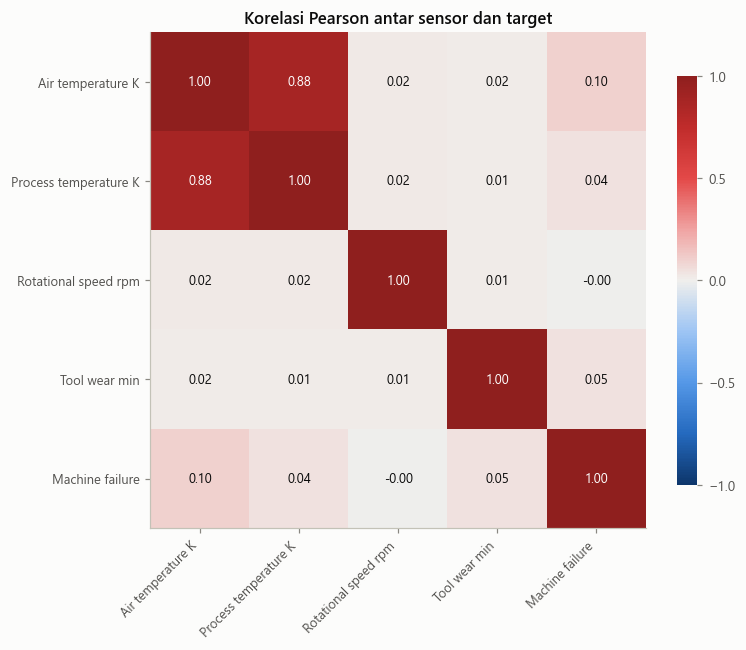

In [9]:
sec("1.6  Matriks korelasi")
num = raw[RAW_FEATURES + [TARGET]]
corr = num.corr()
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
lab = [c.replace(" [", "\n[") for c in corr.columns]
ax.set_xticks(range(len(lab)), lab, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(lab)), lab, fontsize=8.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="#ffffff" if abs(v) > 0.55 else INK)
ax.grid(False)
ax.set_title("Korelasi Pearson antar sensor dan target", fontsize=11)
cb = fig.colorbar(im, ax=ax, shrink=0.8, ticks=[-1, -0.5, 0, 0.5, 1])
cb.outline.set_visible(False)
cb.ax.tick_params(colors=MUTED, labelcolor=INK_2)
fig.tight_layout()
plt.show()

In [10]:
sec("KESIMPULAN TAHAP 1")
print(f"- {n} baris, {raw.shape[1]} kolom, tanpa missing value, "
      f"{int(raw.duplicated().sum())} baris duplikat penuh.")
print(f"- Kelas gagal {n_pos} ({n_pos / n:.2%}); imbalance ratio {ir:.1f}:1.")
print(f"- Baseline majority-class = {n_neg / n:.2%} accuracy tanpa mendeteksi apa pun.")
ct = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("- Korelasi |Pearson| terhadap target, terkuat ke terlemah:")
for k in ct.index:
    print(f"    {k:26s} {corr.loc[k, TARGET]:+.3f}")
print(f"- Fitur berkorelasi terkuat adalah {ct.index[0]} ({corr.loc[ct.index[0], TARGET]:+.3f}).")
print("  Semua korelasi linier lemah (|r| < 0.2): sinyal kegagalan bersifat")
print("  interaksi antar-variabel dan ambang, bukan linier tunggal.")
_r_temp = corr.loc["Air temperature K", "Process temperature K"]
print(f"- Air temp vs Process temp berkorelasi {_r_temp:.3f}.")
print("  Kolinearitas inilah alasan Temp_diff dibuat di TAHAP 3.")


KESIMPULAN TAHAP 1
- 9922 baris, 5 kolom, tanpa missing value, 1 baris duplikat penuh.
- Kelas gagal 261 (2.63%); imbalance ratio 37.0:1.
- Baseline majority-class = 97.37% accuracy tanpa mendeteksi apa pun.
- Korelasi |Pearson| terhadap target, terkuat ke terlemah:
    Air temperature K          +0.097
    Tool wear min              +0.045
    Process temperature K      +0.040
    Rotational speed rpm       -0.001
- Fitur berkorelasi terkuat adalah Air temperature K (+0.097).
  Semua korelasi linier lemah (|r| < 0.2): sinyal kegagalan bersifat
  interaksi antar-variabel dan ambang, bukan linier tunggal.
- Air temp vs Process temp berkorelasi 0.876.
  Kolinearitas inilah alasan Temp_diff dibuat di TAHAP 3.


---
## TAHAP 2 — Pencegahan Kebocoran Data

`dataset.csv` hanya memuat empat pembacaan sensor dan satu kolom target. Tidak
ada identifier, tidak ada label mode kegagalan, dan tidak ada kolom yang baru
tersedia **sesudah** kegagalan terjadi — jadi tidak ada kandidat leakage berupa
kolom yang perlu dibuang.

Yang tetap harus dijaga adalah leakage **prosedural**: scaler dan resampler
wajib di-fit di dalam fold, bukan pada seluruh data. Itu ditegakkan secara
struktural lewat `imblearn.pipeline.Pipeline` di TAHAP 4-5.


In [12]:
sec("2.1  Inventaris kolom dan perlakuannya")
inventaris = pd.DataFrame(
    [(c, "fitur sensor", "dipakai mentah + jadi basis fitur turunan")
     for c in RAW_FEATURES]
    + [(TARGET, "target", "label biner yang diprediksi")],
    columns=["kolom", "kategori", "perlakuan"])
print(inventaris.to_string(index=False))

dibuang = [c for c in raw.columns if c not in RAW_FEATURES + [TARGET, "cycle"]]
print(f"\nKolom di luar 4 sensor + target : {dibuang or 'tidak ada'}")
print("Tidak ada kolom yang dibuang karena tidak ada yang perlu dibuang.")
print()
print("Konsekuensi yang jujur: tanpa kolom mode kegagalan, konsistensi label")
print("tidak bisa divalidasi silang dan recall tidak bisa dipecah per mekanisme")
print("di TAHAP 8. Machine failure dipakai apa adanya sebagai ground truth.")



2.1  Inventaris kolom dan perlakuannya
                kolom     kategori                                 perlakuan
    Air temperature K fitur sensor dipakai mentah + jadi basis fitur turunan
Process temperature K fitur sensor dipakai mentah + jadi basis fitur turunan
 Rotational speed rpm fitur sensor dipakai mentah + jadi basis fitur turunan
        Tool wear min fitur sensor dipakai mentah + jadi basis fitur turunan
      Machine failure       target               label biner yang diprediksi

Kolom di luar 4 sensor + target : tidak ada
Tidak ada kolom yang dibuang karena tidak ada yang perlu dibuang.

Konsekuensi yang jujur: tanpa kolom mode kegagalan, konsistensi label
tidak bisa divalidasi silang dan recall tidak bisa dipecah per mekanisme
di TAHAP 8. Machine failure dipakai apa adanya sebagai ground truth.


---
## TAHAP 3 — Feature Engineering

In [14]:
def buat_fitur(df):
    """Turunan hanya dari 4 sensor yang tersedia. Tidak ada torsi/daya."""
    X = pd.DataFrame(index=df.index)
    for asli, pendek in SHORT.items():
        X[pendek] = df[asli].astype(float)
    X["Temp_diff"] = X["proc_temp_K"] - X["air_temp_K"]
    X["Temp_ratio"] = X["proc_temp_K"] / X["air_temp_K"]
    X["Wear_x_rpm"] = X["tool_wear_min"] * X["rpm"]
    X["Cooling_margin_rate"] = X["Temp_diff"] / X["rpm"]
    X["Thermal_wear_load"] = X["Temp_diff"] * X["tool_wear_min"]
    return X[FEATURES]


X = buat_fitur(raw)
y = raw[TARGET].astype(int).to_numpy()

sec("3.1  Rasional fisik tiap fitur turunan")
rasional = pd.DataFrame([
    ("Temp_diff", "proc_temp_K - air_temp_K",
     "margin heat dissipation; panas yang tidak terbuang ke lingkungan"),
    ("Temp_ratio", "proc_temp_K / air_temp_K",
     "beban termal relatif terhadap suhu ambient, bukan absolut"),
    ("Wear_x_rpm", "tool_wear_min * rpm",
     "akumulasi revolusi ~ total paparan abrasif pada mata pahat"),
    ("Cooling_margin_rate", "Temp_diff / rpm",
     "kecukupan pembuangan panas per satuan kecepatan putar"),
    ("Thermal_wear_load", "Temp_diff * tool_wear_min",
     "interaksi beban termal x keausan; degradasi tidak aditif"),
], columns=["fitur", "rumus", "rasional fisik"])
print(rasional.to_string(index=False))

print("\nTIDAK dibuat, dan alasannya:")
print("  - Fitur torsi/daya apa pun. Dataset ini tidak memuat torsi, dan")
print("    merekonstruksinya dari rpm berarti mengarang variabel yang tidak diukur.")
print("  - Indikator ambang hasil menebak aturan pembangkit label (mis.")
print("    Temp_diff < 8.6 & rpm < 1380). Itu bukan domain knowledge melainkan")
print("    menyalin label ke dalam fitur -> leakage terselubung.")


3.1  Rasional fisik tiap fitur turunan
              fitur                     rumus                                                   rasional fisik
          Temp_diff  proc_temp_K - air_temp_K margin heat dissipation; panas yang tidak terbuang ke lingkungan
         Temp_ratio  proc_temp_K / air_temp_K        beban termal relatif terhadap suhu ambient, bukan absolut
         Wear_x_rpm       tool_wear_min * rpm       akumulasi revolusi ~ total paparan abrasif pada mata pahat
Cooling_margin_rate           Temp_diff / rpm            kecukupan pembuangan panas per satuan kecepatan putar
  Thermal_wear_load Temp_diff * tool_wear_min         interaksi beban termal x keausan; degradasi tidak aditif

TIDAK dibuat, dan alasannya:
  - Fitur torsi/daya apa pun. Dataset ini tidak memuat torsi, dan
    merekonstruksinya dari rpm berarti mengarang variabel yang tidak diukur.
  - Indikator ambang hasil menebak aturan pembangkit label (mis.
    Temp_diff < 8.6 & rpm < 1380). Itu bukan domain know

In [15]:
sec("3.2  Daftar fitur FINAL")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i}. {f:22s} ({'sensor mentah' if f in SHORT.values() else 'turunan'})")
print(f"\nTotal {len(FEATURES)} fitur, semuanya berasal dari empat sensor yang diukur.")
print("\nStatistik fitur final:")
print(X.describe().T.to_string(float_format=lambda v: f"{v:12.4f}"))
print("\nKorelasi terhadap target:")
print(pd.Series({f: np.corrcoef(X[f], y)[0, 1] for f in FEATURES}).sort_values(
    key=np.abs, ascending=False).to_string(float_format=lambda v: f"{v:+.4f}"))


3.2  Daftar fitur FINAL
  1. air_temp_K             (sensor mentah)
  2. proc_temp_K            (sensor mentah)
  3. rpm                    (sensor mentah)
  4. tool_wear_min          (sensor mentah)
  5. Temp_diff              (turunan)
  6. Temp_ratio             (turunan)
  7. Wear_x_rpm             (turunan)
  8. Cooling_margin_rate    (turunan)
  9. Thermal_wear_load      (turunan)

Total 9 fitur, semuanya berasal dari empat sensor yang diukur.

Statistik fitur final:
                           count         mean          std          min          25%          50%          75%          max
air_temp_K             9922.0000     300.0060       2.0007     295.3000     298.3000     300.1000     301.5000     304.5000
proc_temp_K            9922.0000     310.0052       1.4833     305.7000     308.8000     310.1000     311.1000     313.8000
rpm                    9922.0000    1540.2268     179.1594    1168.0000    1425.0000    1505.0000    1613.0000    2886.0000
tool_wear_min          99

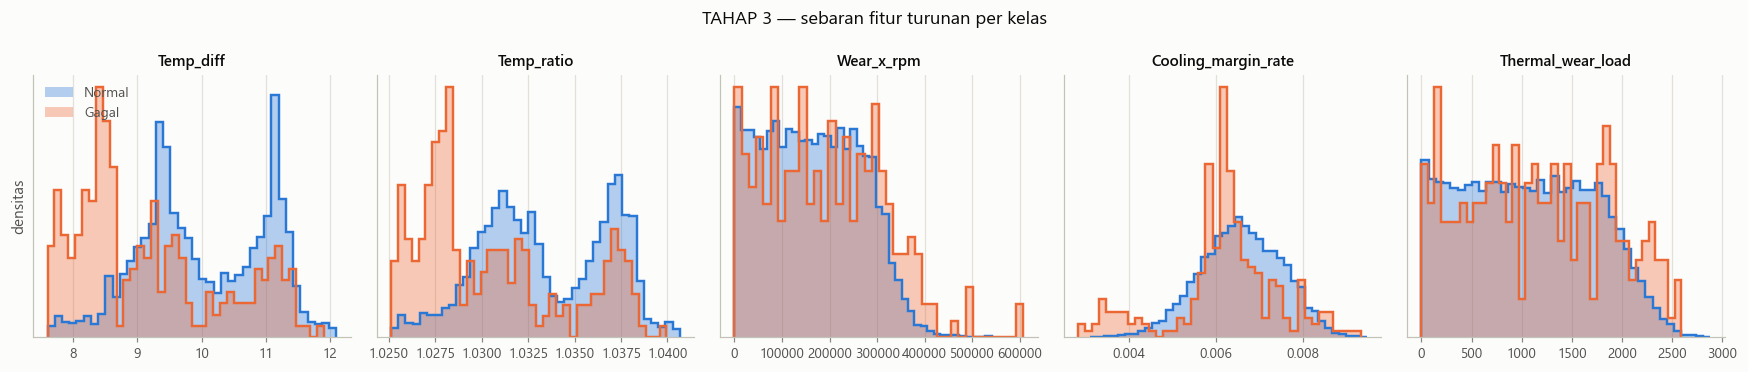

In [16]:
fig, axes = plt.subplots(1, len(ENG_FEATURES), figsize=(16, 3.4))
for ax, f in zip(axes, ENG_FEATURES):
    for kelas, label in [(0, "Normal"), (1, "Gagal")]:
        sub = X.loc[y == kelas, f]
        ax.hist(sub, bins=40, density=True, histtype="stepfilled",
                color=WARNA_KELAS[kelas], alpha=0.35, label=label)
        ax.hist(sub, bins=40, density=True, histtype="step",
                color=WARNA_KELAS[kelas], linewidth=1.6)
    ax.set_title(f, fontsize=10)
    ax.set_yticks([])
axes[0].legend(loc="upper left")
axes[0].set_ylabel("densitas")
fig.suptitle("TAHAP 3 — sebaran fitur turunan per kelas", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

In [17]:
sec("KESIMPULAN TAHAP 2-3")
print("- Tidak ada kolom identifier maupun label mode di dataset ini, jadi nol")
print("  kolom dibuang dan tidak ada kandidat target leakage.")
print(f"- {len(FEATURES)} fitur final = 4 sensor + {len(ENG_FEATURES)} turunan fisika.")
_ct3 = pd.Series({f: abs(np.corrcoef(X[f], y)[0, 1]) for f in FEATURES}
                 ).sort_values(ascending=False)
print(f"- |Korelasi| terkuat terhadap target: {_ct3.index[0]} ({_ct3.iloc[0]:.3f}).")
print("- Konsekuensi tanpa kolom mode: validasi konsistensi label dan diagnostik")
print("  recall per mekanisme kegagalan tidak tersedia di studi ini.")



KESIMPULAN TAHAP 2-3
- Tidak ada kolom identifier maupun label mode di dataset ini, jadi nol
  kolom dibuang dan tidak ada kandidat target leakage.
- 9 fitur final = 4 sensor + 5 turunan fisika.
- |Korelasi| terkuat terhadap target: Temp_diff (0.136).
- Konsekuensi tanpa kolom mode: validasi konsistensi label dan diagnostik
  recall per mekanisme kegagalan tidak tersedia di studi ini.


---
## TAHAP 4 — Skema Validasi

In [19]:
sec("4.1  Split stratified 80/20")
X_tr_df, X_te_df, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RS)
X_tr, X_te = X_tr_df.to_numpy(), X_te_df.to_numpy()

print(f"Train : {len(y_tr):5d} baris | positif {int(y_tr.sum()):3d} ({y_tr.mean():.3%})")
print(f"Test  : {len(y_te):5d} baris | positif {int(y_te.sum()):3d} ({y_te.mean():.3%})")
print(f"Proporsi positif terjaga: train {y_tr.mean():.4f} vs test {y_te.mean():.4f} "
      f"vs penuh {y.mean():.4f}")
print("\nTest set DIKUNCI mulai titik ini. Tidak disentuh sampai TAHAP 7.")

BASELINE_MAYORITAS = 1 - y_te.mean()


4.1  Split stratified 80/20
Train :  7937 baris | positif 209 (2.633%)
Test  :  1985 baris | positif  52 (2.620%)
Proporsi positif terjaga: train 0.0263 vs test 0.0262 vs penuh 0.0263

Test set DIKUNCI mulai titik ini. Tidak disentuh sampai TAHAP 7.


In [20]:
sec("4.2  StratifiedKFold 5-fold di dalam train")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
tab = pd.DataFrame([
    {"fold": i, "n_train": len(itr), "pos_train": int(y_tr[itr].sum()),
     "n_val": len(iva), "pos_val": int(y_tr[iva].sum()),
     "pct_pos_val": y_tr[iva].mean()}
    for i, (itr, iva) in enumerate(skf.split(X_tr, y_tr), 1)])
print(tab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nRata-rata hanya {tab.pos_val.mean():.1f} kegagalan per fold validasi.")
print("Konsekuensinya estimasi recall punya varians besar -> TAHAP 7 menjalankan")
print("uji stabilitas 5 seed, bukan melaporkan satu angka telanjang.")
print("\nCATATAN ANTI-LEAKAGE:")
print("  StandardScaler dan SMOTE TIDAK di-fit di sini. Keduanya jadi step di")
print("  dalam imblearn.pipeline.Pipeline, sehingga sklearn memanggil fit() ulang")
print("  pada subset train setiap fold. Fit di luar fold membuat statistik data")
print("  validasi bocor ke preprocessing dan skor CV jadi optimistis.")


4.2  StratifiedKFold 5-fold di dalam train
 fold  n_train  pos_train  n_val  pos_val  pct_pos_val
    1     6349        167   1588       42       0.0264
    2     6349        167   1588       42       0.0264
    3     6350        168   1587       41       0.0258
    4     6350        167   1587       42       0.0265
    5     6350        167   1587       42       0.0265

Rata-rata hanya 41.8 kegagalan per fold validasi.
Konsekuensinya estimasi recall punya varians besar -> TAHAP 7 menjalankan
uji stabilitas 5 seed, bukan melaporkan satu angka telanjang.

CATATAN ANTI-LEAKAGE:
  StandardScaler dan SMOTE TIDAK di-fit di sini. Keduanya jadi step di
  dalam imblearn.pipeline.Pipeline, sehingga sklearn memanggil fit() ulang
  pada subset train setiap fold. Fit di luar fold membuat statistik data
  validasi bocor ke preprocessing dan skor CV jadi optimistis.


---
## TAHAP 5 — Penanganan Class Imbalance

Lima strategi dibandingkan, semuanya dijalankan **di dalam** pipeline CV:

1. `baseline` — tanpa penanganan
2. `class_weight` — `class_weight='balanced'` / `scale_pos_weight`
3. `SMOTE`
4. `SMOTETomek`
5. `Jitter` — menyalin titik minoritas nyata lalu menggesernya sedikit

Strategi kelima ditambahkan atas keberatan yang sah terhadap SMOTE: SMOTE
menempatkan titik sintetis di **garis antara dua tetangga minoritas**, dan
kalau kedua kegagalan itu mekanismenya berbeda, titik tengahnya bisa berupa
kondisi mesin yang tidak pernah terjadi. Jitter menghindari itu karena setiap
titik sintetisnya adalah satu pengamatan nyata yang digeser sedikit.

Sel 5.0 di bawah menguji keberatan itu dengan angka, bukan menerimanya
begitu saja.

In [22]:
class KerasFNNClassifier(ClassifierMixin, BaseEstimator):
    """
    Feedforward NN 2-3 hidden layer + dropout + early stopping.

    scikeras tidak terinstall, jadi wrapper ini dibuat manual. ClassifierMixin
    HARUS di depan BaseEstimator: sklearn>=1.6 merangkai __sklearn_tags__ lewat
    MRO, dan kalau urutannya terbalik estimator dibaca sebagai regressor
    sehingga scorer average_precision menolak predict_proba.
    """

    def __init__(self, hidden=(64, 32), dropout=0.3, lr=1e-3, batch_size=256,
                 epochs=150, patience=15, class_weight=None, random_state=RS,
                 verbose=0):
        self.hidden = hidden
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.class_weight = class_weight
        self.random_state = random_state
        self.verbose = verbose

    def _bangun(self, n_fitur):
        import keras
        from keras import layers
        keras.utils.set_random_seed(self.random_state)
        model = keras.Sequential([keras.Input(shape=(n_fitur,))])
        for unit in self.hidden:
            model.add(layers.Dense(unit, activation="relu"))
            model.add(layers.Dropout(self.dropout))
        model.add(layers.Dense(1, activation="sigmoid"))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=self.lr),
                      loss="binary_crossentropy",
                      metrics=[keras.metrics.AUC(curve="PR", name="pr_auc")])
        return model

    def fit(self, X, y):
        import keras
        X = np.asarray(X, dtype="float32")
        y = np.asarray(y).astype("float32").ravel()
        self.classes_ = np.unique(y).astype(int)
        self.n_features_in_ = X.shape[1]

        cw = None
        if self.class_weight == "balanced":
            n_ = len(y)
            n_p = max(y.sum(), 1.0)
            n_n = max(n_ - n_p, 1.0)
            cw = {0: n_ / (2 * n_n), 1: n_ / (2 * n_p)}
        elif isinstance(self.class_weight, dict):
            cw = self.class_weight

        self.model_ = self._bangun(X.shape[1])
        es = keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                           patience=self.patience,
                                           restore_best_weights=True, verbose=0)
        self.model_.fit(X, y, validation_split=0.15, epochs=self.epochs,
                        batch_size=self.batch_size, class_weight=cw,
                        callbacks=[es], shuffle=True, verbose=self.verbose)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "model_")
        p = self.model_.predict(np.asarray(X, dtype="float32"),
                                batch_size=1024, verbose=0).ravel()
        return np.column_stack([1.0 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.classifier_tags.multi_class = False
        tags.non_deterministic = True
        return tags


SPW = (len(y_tr) - y_tr.sum()) / y_tr.sum()   # negatif/positif pada TRAIN saja
print(f"scale_pos_weight dari train = {SPW:.2f}")


def buat_model(nama, strategi, random_state=RS):
    seimbang = strategi == "class_weight"
    if nama == "LogisticRegression":
        return LogisticRegression(max_iter=2000, solver="lbfgs", C=1.0,
                                  class_weight="balanced" if seimbang else None,
                                  random_state=random_state)
    if nama == "RandomForest":
        return RandomForestClassifier(n_estimators=300, min_samples_leaf=1,
                                      n_jobs=-1,
                                      class_weight="balanced" if seimbang else None,
                                      random_state=random_state)
    if nama == "XGBoost":
        return XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric="aucpr", tree_method="hist", n_jobs=-1,
                             scale_pos_weight=SPW if seimbang else 1.0,
                             random_state=random_state)
    if nama == "FNN":
        return KerasFNNClassifier(hidden=(64, 32), dropout=0.3, lr=1e-3,
                                  class_weight="balanced" if seimbang else None,
                                  random_state=random_state)
    raise ValueError(nama)


N_DASAR = len(SHORT)   # 4 kolom pertama FEATURES = sensor mentah


def hitung_turunan_np(A):
    """
    Isi ulang kelima kolom turunan dari empat kolom sensor.
    Urutan kolom mengikuti FEATURES: [air, proc, rpm, wear, +5 turunan].
    """
    air, proc, rpm, wear = A[:, 0], A[:, 1], A[:, 2], A[:, 3]
    A[:, 4] = proc - air                # Temp_diff
    A[:, 5] = proc / air                # Temp_ratio
    A[:, 6] = wear * rpm                # Wear_x_rpm
    A[:, 7] = (proc - air) / rpm        # Cooling_margin_rate
    A[:, 8] = (proc - air) * wear       # Thermal_wear_load
    return A


class JitterOversampler(BaseOverSampler):
    """
    Oversampling dengan menyalin titik minoritas nyata lalu menggesernya sedikit.

    Bedanya dengan SMOTE. SMOTE menaruh titik baru di GARIS ANTARA dua tetangga
    minoritas. Kalau kedua kegagalan itu mekanismenya berbeda — misalnya satu
    kegagalan termal pada putaran rendah dan satu kegagalan beban pada putaran
    tinggi — titik tengahnya
    bisa berupa kondisi mesin yang tidak pernah, bahkan tidak bisa, terjadi.
    Jitter tidak punya masalah itu: setiap titik sintetis adalah satu pengamatan
    nyata yang digeser sedikit, jadi ia tetap berada di sekitar kondisi yang
    memang pernah dialami mesin.

    Dua penjagaan supaya hasilnya benar-benar tetap fisis:

    1. Hanya empat sensor mentah yang digeser; kelima fitur turunan DIHITUNG
       ULANG dari sensor yang sudah digeser. Kalau kesembilan kolom digeser
       sendiri-sendiri, Temp_diff tidak lagi sama dengan proc - air dan titiknya
       justru jadi mustahil — persis kebalikan dari tujuannya.
    2. Hasil geseran di-clip ke rentang yang benar-benar teramati pada data
       latih fold itu, jadi tidak ada nilai yang keluar dari envelope operasi.

    sigma adalah besar geseran sebagai pecahan dari simpangan baku tiap sensor.
    sigma=0.05 pada dataset ini berarti sekitar +-9 rpm, +-0.1 K, +-3 menit
    tool wear — cukup untuk memberi variasi, terlalu kecil untuk memindahkan
    titik ke rezim operasi yang lain.
    """

    def __init__(self, sampling_strategy="auto", sigma=0.05, n_dasar=N_DASAR,
                 random_state=None):
        super().__init__(sampling_strategy=sampling_strategy)
        self.sigma = sigma
        self.n_dasar = n_dasar
        self.random_state = random_state

    def _fit_resample(self, X, y):
        rng = check_random_state(self.random_state)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        d = self.n_dasar

        lo, hi = X[:, :d].min(axis=0), X[:, :d].max(axis=0)
        skala = self.sigma * X[:, :d].std(axis=0)

        Xb, yb = [X], [y]
        for kelas, n_tambah in self.sampling_strategy_.items():
            if n_tambah <= 0:
                continue
            sumber = X[y == kelas]
            baru = sumber[rng.randint(0, len(sumber), n_tambah)].copy()
            baru[:, :d] = np.clip(
                baru[:, :d] + rng.normal(0.0, 1.0, (n_tambah, d)) * skala, lo, hi)
            Xb.append(hitung_turunan_np(baru))
            yb.append(np.full(n_tambah, kelas, dtype=y.dtype))

        return np.vstack(Xb), np.concatenate(yb)


def buat_pipeline(nama, strategi, random_state=RS):
    """
    pra_resampler -> scaler -> resampler -> model.

    Kenapa ada DUA slot resampler, bukan satu:
      - SMOTE/SMOTETomek harus jalan SESUDAH scaler. Jaraknya Euclidean, dan
        pada satuan asli Wear_x_rpm (rentang 0-607.375) akan menenggelamkan
        Temp_diff (rentang 7,6-12,1) sehingga "tetangga terdekat" praktis
        ditentukan satu fitur saja.
      - Jitter harus jalan SEBELUM scaler, karena ia menggeser sensor dalam
        satuan fisik lalu menghitung ulang fitur turunan. Itu mustahil
        dikerjakan pada data yang sudah distandardisasi.

    Anti-leakage tetap terjaga secara struktural: sklearn memanggil
    pipeline.fit per fold, jadi setiap fit di sini - scaler maupun resampler -
    hanya melihat subset train fold itu. Kedua slot resampler juga otomatis
    nonaktif saat predict, sehingga data validasi tidak pernah ikut di-resample
    maupun ditambahi titik sintetis.
    """
    pra, res = "passthrough", "passthrough"
    if strategi == "SMOTE":
        res = SMOTE(random_state=random_state, k_neighbors=5)
    elif strategi == "SMOTETomek":
        res = SMOTETomek(random_state=random_state,
                         smote=SMOTE(random_state=random_state, k_neighbors=5))
    elif strategi == "Jitter":
        pra = JitterOversampler(sigma=0.05, random_state=random_state)

    return Pipeline([("pra_resampler", pra),
                     ("scaler", StandardScaler()),
                     ("resampler", res),
                     ("model", buat_model(nama, strategi, random_state))])

scale_pos_weight dari train = 36.98


In [23]:
sec("5.0  Menguji klaim: apakah titik sintetis SMOTE masuk akal secara fisik?")
print("Kelima fitur turunan adalah fungsi deterministik dari empat sensor.")
print("Titik sintetis yang sah HARUS memenuhi hubungan itu. Kalau tidak, ia")
print("mewakili mesin yang tidak mungkin ada: misalnya Wear_x_rpm yang bukan")
print("hasil kali tool wear dan rpm-nya sendiri.\n")

_smote = SMOTE(random_state=RS, k_neighbors=5)
_jit = JitterOversampler(sigma=0.05, random_state=RS)
Xs, ys = _smote.fit_resample(X_tr, y_tr)
Xj, yj = _jit.fit_resample(X_tr, y_tr)

_periksa = [
    ("Temp_diff", 4, lambda A: A[:, 1] - A[:, 0], "linier"),
    ("Temp_ratio", 5, lambda A: A[:, 1] / A[:, 0], "NONLINIER"),
    ("Wear_x_rpm", 6, lambda A: A[:, 3] * A[:, 2], "NONLINIER"),
    ("Cooling_margin_rate", 7, lambda A: (A[:, 1] - A[:, 0]) / A[:, 2], "NONLINIER"),
    ("Thermal_wear_load", 8, lambda A: (A[:, 1] - A[:, 0]) * A[:, 3], "NONLINIER"),
]
n_asli = len(X_tr)
tabel = []
for nama_f, kol, rumus, sifat in _periksa:
    for label, A in [("SMOTE", Xs[n_asli:]), ("Jitter", Xj[n_asli:])]:
        galat = np.abs(A[:, kol] - rumus(A))
        rel = galat / (np.abs(rumus(A)) + 1e-12)
        tabel.append({"fitur": nama_f, "sifat": sifat, "metode": label,
                      "galat_rata2": galat.mean(), "galat_maks": galat.max(),
                      "galat_relatif_maks": rel.max(),
                      "n_titik_melanggar": int((rel > 1e-9).sum())})
konsistensi = pd.DataFrame(tabel)
print(f"Titik sintetis dibuat: SMOTE {len(Xs) - n_asli}, Jitter {len(Xj) - n_asli}")
print()
print(konsistensi.to_string(index=False, float_format=lambda v: f"{v:.6g}"))

_lgr = konsistensi[(konsistensi.metode == "SMOTE") & (konsistensi.sifat == "NONLINIER")]
print()
print("HASILNYA MEMBENARKAN KEBERATAN ITU, dengan satu koreksi penting:")
print("  - Temp_diff = proc - air adalah fungsi LINIER. Interpolasi SMOTE")
print("    mempertahankannya persis, jadi di kolom itu SMOTE tidak salah.")
print(f"  - Empat turunan lain NONLINIER, dan di situ SMOTE melanggar:")
print(f"    {int(_lgr.n_titik_melanggar.max())} dari {len(Xs) - n_asli} titik sintetis punya")
print(f"    fitur turunan yang tidak konsisten dengan sensornya sendiri,")
print(f"    galat relatif sampai {_lgr.galat_relatif_maks.max():.1%}.")
print("  - Jitter nol pelanggaran, karena turunannya memang dihitung ulang.")
print()
print("Jadi keberatannya benar, tapi bukan karena 'titik tengah dua kegagalan'")
print("saja. Sebab yang lebih tajam dan terukur: interpolasi linier tidak")
print("mengawetkan hubungan nonlinier antar-fitur. Apakah itu betul merugikan")
print("performa, tetap harus dibuktikan oleh PR-AUC di bawah - bukan oleh")
print("argumen fisika ini sendirian.")


5.0  Menguji klaim: apakah titik sintetis SMOTE masuk akal secara fisik?
Kelima fitur turunan adalah fungsi deterministik dari empat sensor.
Titik sintetis yang sah HARUS memenuhi hubungan itu. Kalau tidak, ia
mewakili mesin yang tidak mungkin ada: misalnya Wear_x_rpm yang bukan
hasil kali tool wear dan rpm-nya sendiri.

Titik sintetis dibuat: SMOTE 7519, Jitter 7519

              fitur     sifat metode  galat_rata2  galat_maks  galat_relatif_maks  n_titik_melanggar
          Temp_diff    linier  SMOTE   1.7859e-14 5.68434e-14         6.98594e-15                  0
          Temp_diff    linier Jitter            0           0                   0                  0
         Temp_ratio NONLINIER  SMOTE  6.55422e-06 6.03858e-05         5.84804e-05               7103
         Temp_ratio NONLINIER Jitter            0           0                   0                  0
         Wear_x_rpm NONLINIER  SMOTE         2280     39180.1            0.883458               7006
         Wear_x_rpm NO

In [24]:
sec("5.1  Menjalankan 4 model x 5 strategi dengan 5-fold CV")
print("Metrik ambang (Recall/Precision/F1/Accuracy) dihitung pada threshold 0.5")
print("bawaan; optimasi threshold baru dikerjakan di TAHAP 7.\n")

SKOR = {"PR_AUC": "average_precision", "ROC_AUC": "roc_auc", "Recall": "recall",
        "Precision": "precision", "F1": "f1", "Accuracy": "accuracy"}

baris = []
for nama in NAMA_MODEL:
    for strategi in NAMA_STRATEGI:
        t0 = time.time()
        cv = cross_validate(buat_pipeline(nama, strategi), X_tr, y_tr, cv=skf,
                            scoring=SKOR, n_jobs=1, error_score="raise")
        rec = {"model": nama, "strategi": strategi}
        for label in SKOR:
            rec[label] = cv[f"test_{label}"].mean()
            rec[f"{label}_std"] = cv[f"test_{label}"].std()
        rec["detik"] = time.time() - t0
        baris.append(rec)
        print(f"  {nama:20s} {strategi:13s} "
              f"PR-AUC {rec['PR_AUC']:.4f}+-{rec['PR_AUC_std']:.4f}  "
              f"Recall {rec['Recall']:.4f}  Prec {rec['Precision']:.4f}  "
              f"({rec['detik']:.1f}s)")

cv5 = pd.DataFrame(baris)



5.1  Menjalankan 4 model x 5 strategi dengan 5-fold CV
Metrik ambang (Recall/Precision/F1/Accuracy) dihitung pada threshold 0.5
bawaan; optimasi threshold baru dikerjakan di TAHAP 7.

  LogisticRegression   baseline      PR-AUC 0.2814+-0.0500  Recall 0.0333  Prec 0.5167  (0.1s)
  LogisticRegression   class_weight  PR-AUC 0.2206+-0.0536  Recall 0.8228  Prec 0.0883  (0.2s)
  LogisticRegression   SMOTE         PR-AUC 0.2120+-0.0504  Recall 0.8228  Prec 0.0932  (0.3s)
  LogisticRegression   SMOTETomek    PR-AUC 0.2137+-0.0501  Recall 0.8228  Prec 0.0933  (0.8s)
  LogisticRegression   Jitter        PR-AUC 0.2193+-0.0504  Recall 0.8228  Prec 0.0894  (0.3s)
  RandomForest         baseline      PR-AUC 0.6102+-0.0413  Recall 0.5264  Prec 0.9252  (6.2s)
  RandomForest         class_weight  PR-AUC 0.6005+-0.0287  Recall 0.4929  Prec 0.9571  (6.0s)
  RandomForest         SMOTE         PR-AUC 0.5638+-0.0226  Recall 0.5741  Prec 0.3533  (11.2s)
  RandomForest         SMOTETomek    PR-AUC 0.5626+-0.

In [25]:
sec("5.2  Tabel hasil lengkap")
print(cv5[["model", "strategi", "PR_AUC", "PR_AUC_std", "ROC_AUC", "Recall",
           "Precision", "F1", "Accuracy"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))

sec("5.3  Rata-rata tiap strategi lintas keempat model")
agg5 = cv5.groupby("strategi")[["PR_AUC", "ROC_AUC", "Recall", "Precision", "F1",
                                "Accuracy"]].mean().reindex(NAMA_STRATEGI)
print(agg5.to_string(float_format=lambda v: f"{v:.4f}"))

sec("5.4  Trade-off recall vs precision")
base = agg5.loc["baseline"]
for s in NAMA_STRATEGI[1:]:
    r = agg5.loc[s]
    print(f"{s:13s} recall {base.Recall:.3f} -> {r.Recall:.3f} "
          f"({r.Recall - base.Recall:+.3f})   "
          f"precision {base.Precision:.3f} -> {r.Precision:.3f} "
          f"({r.Precision - base.Precision:+.3f})   "
          f"PR-AUC {base.PR_AUC:.3f} -> {r.PR_AUC:.3f} ({r.PR_AUC - base.PR_AUC:+.3f})")
print()
print("Cara membacanya: PR-AUC dihitung dari seluruh kurva precision-recall dan")
print("TIDAK bergantung threshold, jadi ia mengukur kualitas ranking probabilitas.")
print("Recall/Precision di tabel ini terikat threshold 0.5. Resampling dan")
print("class_weight terutama menggeser kalibrasi probabilitas ke atas sehingga")
print("lebih banyak sampel melewati 0.5. Kalau PR-AUC tidak ikut naik, artinya")
print("rankingnya tidak membaik: efek yang sama bisa dicapai gratis dengan")
print("menurunkan threshold, tanpa biaya distorsi distribusi.")


5.2  Tabel hasil lengkap
             model     strategi  PR_AUC  PR_AUC_std  ROC_AUC  Recall  Precision     F1  Accuracy
LogisticRegression     baseline  0.2814      0.0500   0.8446  0.0333     0.5167 0.0622    0.9739
LogisticRegression class_weight  0.2206      0.0536   0.8687  0.8228     0.0883 0.1594    0.7711
LogisticRegression        SMOTE  0.2120      0.0504   0.8675  0.8228     0.0932 0.1674    0.7839
LogisticRegression   SMOTETomek  0.2137      0.0501   0.8674  0.8228     0.0933 0.1676    0.7842
LogisticRegression       Jitter  0.2193      0.0504   0.8692  0.8228     0.0894 0.1613    0.7742
      RandomForest     baseline  0.6102      0.0413   0.8952  0.5264     0.9252 0.6709    0.9864
      RandomForest class_weight  0.6005      0.0287   0.8873  0.4929     0.9571 0.6503    0.9860
      RandomForest        SMOTE  0.5638      0.0226   0.8980  0.5741     0.3533 0.4365    0.9607
      RandomForest   SMOTETomek  0.5626      0.0384   0.8994  0.5693     0.3431 0.4276    0.9597
    

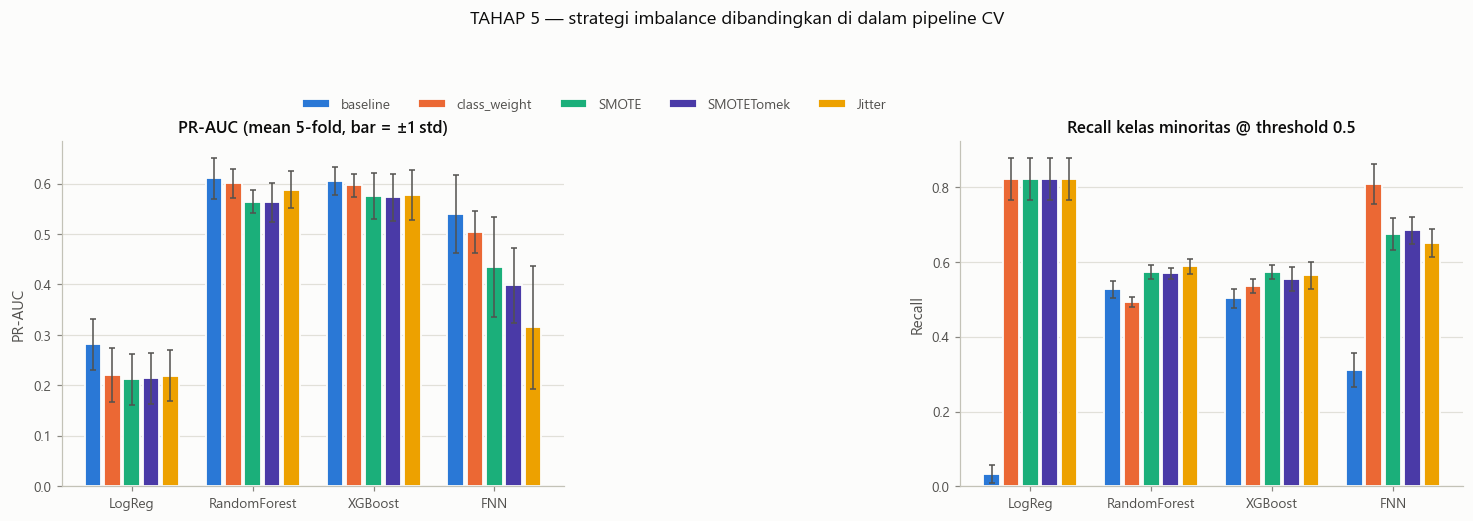

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
xs = np.arange(len(NAMA_MODEL))
ns = len(NAMA_STRATEGI)
lebar = 0.8 / ns
for ax, metrik_nama, judul in [
    (axes[0], "PR_AUC", "PR-AUC (mean 5-fold, bar = ±1 std)"),
    (axes[1], "Recall", "Recall kelas minoritas @ threshold 0.5"),
]:
    for j, s in enumerate(NAMA_STRATEGI):
        sub = cv5[cv5.strategi == s].set_index("model").reindex(NAMA_MODEL)
        ax.bar(xs + (j - (ns - 1) / 2) * lebar, sub[metrik_nama], lebar * 0.86,
               label=s, color=WARNA_STRATEGI[s], yerr=sub[f"{metrik_nama}_std"],
               error_kw=dict(ecolor=INK_2, lw=1, capsize=2),
               edgecolor=SURFACE, linewidth=1.2)
    ax.set_xticks(xs, ["LogReg", "RandomForest", "XGBoost", "FNN"])
    ax.set_title(judul, fontsize=11)
    ax.grid(axis="x", visible=False)
    ax.set_ylim(0, None)
axes[0].set_ylabel("PR-AUC")
axes[1].set_ylabel("Recall")
axes[0].legend(ncols=5, loc="upper center", bbox_to_anchor=(1.06, 1.16))
fig.suptitle("TAHAP 5 — strategi imbalance dibandingkan di dalam pipeline CV",
             fontsize=12, color=INK, y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [27]:
sec("KESIMPULAN TAHAP 5")
terbaik5 = cv5.loc[cv5.PR_AUC.idxmax()]
print(f"- PR-AUC CV tertinggi: {terbaik5.model} + {terbaik5.strategi} = "
      f"{terbaik5.PR_AUC:.4f} (+-{terbaik5.PR_AUC_std:.4f})")
best_per_model = cv5.loc[cv5.groupby("model").PR_AUC.idxmax()].set_index("model")
print("- Strategi terbaik per model menurut PR-AUC:")
for m in NAMA_MODEL:
    r = best_per_model.loc[m]
    print(f"    {m:20s} -> {r.strategi:13s} PR-AUC {r.PR_AUC:.4f}  recall {r.Recall:.4f}")
rec5 = cv5.loc[cv5.Recall.idxmax()]
print(f"- Recall tertinggi @0.5: {rec5.model} + {rec5.strategi} = {rec5.Recall:.4f}, "
      f"tapi precision-nya {rec5.Precision:.4f}")
print(f"- Accuracy tertinggi {cv5.Accuracy.max():.4f} vs baseline majority-class "
      f"{n_neg / n:.4f}")
print("  -> selisih tipis, konfirmasi accuracy tidak informatif pada rasio ini.")


KESIMPULAN TAHAP 5
- PR-AUC CV tertinggi: RandomForest + baseline = 0.6102 (+-0.0413)
- Strategi terbaik per model menurut PR-AUC:
    LogisticRegression   -> baseline      PR-AUC 0.2814  recall 0.0333
    RandomForest         -> baseline      PR-AUC 0.6102  recall 0.5264
    XGBoost              -> baseline      PR-AUC 0.6051  recall 0.5026
    FNN                  -> baseline      PR-AUC 0.5391  recall 0.3111
- Recall tertinggi @0.5: LogisticRegression + class_weight = 0.8228, tapi precision-nya 0.0883
- Accuracy tertinggi 0.9864 vs baseline majority-class 0.9737
  -> selisih tipis, konfirmasi accuracy tidak informatif pada rasio ini.


---
## TAHAP 6 — Pemodelan dan Hyperparameter Tuning

`scoring='average_precision'` (PR-AUC), bukan accuracy. Pada rasio 1:28,5
accuracy dimaksimalkan dengan menebak "normal" terus, jadi ia tidak bisa
memandu pencarian hyperparameter.

Strategi imbalance ikut dijadikan hyperparameter (`resampler` bisa
`passthrough`/SMOTE/SMOTETomek, `class_weight` bisa None/balanced), supaya
pemilihannya tunduk pada kriteria yang sama dan bukan diputuskan tangan.

In [29]:
RESAMPLER = ["passthrough",
             SMOTE(random_state=RS, k_neighbors=5),
             SMOTETomek(random_state=RS, smote=SMOTE(random_state=RS, k_neighbors=5))]
JITTER = [JitterOversampler(sigma=s, random_state=RS) for s in (0.02, 0.05, 0.10)]


def pipa(model):
    return Pipeline([("pra_resampler", "passthrough"),
                     ("scaler", StandardScaler()),
                     ("resampler", "passthrough"), ("model", model)])


def ruang_imbalance(par_model):
    """
    Dua cabang, karena kedua keluarga resampler duduk di slot berbeda:
    SMOTE sesudah scaler (butuh fitur terstandardisasi untuk jarak Euclidean),
    Jitter sebelum scaler (butuh satuan fisik untuk menghitung ulang turunan).
    RandomizedSearchCV menerima list of dict, jadi keduanya bisa diadu langsung.
    """
    return [
        {"pra_resampler": ["passthrough"], "resampler": RESAMPLER, **par_model},
        {"pra_resampler": JITTER, "resampler": ["passthrough"], **par_model},
    ]


RUANG = {
    "LogisticRegression": (
        pipa(LogisticRegression(max_iter=5000, random_state=RS)),
        ruang_imbalance({
            "model__C": loguniform(1e-3, 1e3),
            "model__class_weight": [None, "balanced"],
            "model__penalty": ["l2"], "model__solver": ["lbfgs"]}),
        50),
    "RandomForest": (
        pipa(RandomForestClassifier(n_jobs=-1, random_state=RS)),
        ruang_imbalance({
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 6, 10, 16, 24],
            "model__min_samples_leaf": randint(1, 12),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, None],
            "model__class_weight": [None, "balanced", "balanced_subsample"]}),
        50),
    "XGBoost": (
        pipa(XGBClassifier(eval_metric="aucpr", tree_method="hist", n_jobs=-1,
                           random_state=RS)),
        ruang_imbalance({
            "model__n_estimators": randint(200, 900),
            "model__max_depth": randint(3, 10),
            "model__learning_rate": loguniform(0.01, 0.3),
            "model__subsample": uniform(0.6, 0.4),
            "model__colsample_bytree": uniform(0.6, 0.4),
            "model__min_child_weight": randint(1, 10),
            "model__gamma": uniform(0, 5),
            "model__reg_lambda": loguniform(0.1, 20),
            "model__scale_pos_weight": [1.0, np.sqrt(SPW), SPW]}),
        50),
    "FNN": (
        pipa(KerasFNNClassifier(random_state=RS)),
        ruang_imbalance({
            "model__hidden": [(64, 32), (128, 64), (128, 64, 32), (64, 64, 32),
                              (256, 128, 64)],
            "model__dropout": [0.1, 0.2, 0.3, 0.4],
            "model__lr": loguniform(3e-4, 5e-3),
            "model__batch_size": [128, 256, 512],
            "model__class_weight": [None, "balanced"]}),
        14),   # tiap fit ~10-15 detik, jadi n_iter ditahan
}

# ---------------------------------------------------------------- cache
# Tuning ini memakan puluhan menit. Hasilnya di-cache PER MODEL supaya proses
# yang terputus di tengah tidak menghanguskan model yang sudah selesai, dan
# supaya notebook ini praktis dijalankan ulang. Cache hanya dipakai kalau
# tanda tangannya cocok - begitu seed, daftar fitur, atau budget pencarian
# berubah, cache diabaikan dan pencarian dijalankan ulang.
CACHE_DIR = "cache_klasifikasi"
os.makedirs(CACHE_DIR, exist_ok=True)
PAKAI_CACHE = True


def tanda_tangan(**kw):
    return json.dumps(kw, sort_keys=True, default=str)


SIG6 = tanda_tangan(rs=RS, fitur=FEATURES, ver="6.1",
                    n_iter={k: v[2] for k, v in RUANG.items()})

sec("6.1  RandomizedSearchCV, scoring = average_precision")
print("Tahap ini yang paling lama (RandomForest & FNN).\n")

def label_imbalance(params):
    """Satu label ringkas dari dua slot resampler."""
    pra, res = params.get("pra_resampler"), params.get("resampler")
    if isinstance(pra, JitterOversampler):
        return f"Jitter(sigma={pra.sigma})"
    if res is None or res == "passthrough":
        return "passthrough"
    return type(res).__name__


hasil_tune, est = [], {}
for nama, (pipe, ruang, n_iter) in RUANG.items():
    _f = os.path.join(CACHE_DIR, f"tahap6_{nama}.joblib")
    if PAKAI_CACHE and os.path.exists(_f):
        # Aman: cache ini artefak yang ditulis notebook ini sendiri.
        _c = joblib.load(_f)
        if _c.get("sig") == SIG6:
            est[nama] = _c["est"]
            hasil_tune.append(_c["baris"])
            print(f"  {nama:20s} PR-AUC {_c['baris']['PR_AUC_cv']:.4f}   "
                  f"[dimuat dari cache, strategi {_c['baris']['imbalance']}]")
            continue
    t0 = time.time()
    cari = RandomizedSearchCV(pipe, ruang, n_iter=n_iter,
                              scoring="average_precision", cv=skf,
                              random_state=RS, n_jobs=1, refit=True,
                              error_score="raise")
    cari.fit(X_tr, y_tr)
    dt = time.time() - t0
    est[nama] = cari.best_estimator_

    imb = label_imbalance(cari.best_params_)
    par = {k: (v if not hasattr(v, "get_params") else type(v).__name__)
           for k, v in cari.best_params_.items()}
    par["imbalance"] = imb
    std = pd.DataFrame(cari.cv_results_).loc[cari.best_index_, "std_test_score"]
    hasil_tune.append({"model": nama, "PR_AUC_cv": cari.best_score_,
                       "PR_AUC_cv_std": std, "n_iter": n_iter, "detik": dt,
                       "imbalance": imb,
                       "params": json.dumps(par, default=str)})
    print(f"  {nama:20s} PR-AUC {cari.best_score_:.4f} +-{std:.4f}   "
          f"({dt / 60:.1f} menit, {n_iter} kandidat)")
    print(f"      strategi imbalance terpilih : {imb}")
    for k, v in sorted(par.items()):
        if k not in ("resampler", "pra_resampler", "imbalance"):
            print(f"      {k:32s} {v}")
    print()
    joblib.dump({"sig": SIG6, "est": est[nama], "baris": hasil_tune[-1]}, _f)

tune = pd.DataFrame(hasil_tune).sort_values("PR_AUC_cv", ascending=False)



6.1  RandomizedSearchCV, scoring = average_precision
Tahap ini yang paling lama (RandomForest & FNN).

  LogisticRegression   PR-AUC 0.2749   [dimuat dari cache, strategi passthrough]
  RandomForest         PR-AUC 0.6254   [dimuat dari cache, strategi passthrough]
  XGBoost              PR-AUC 0.6355   [dimuat dari cache, strategi passthrough]
  FNN                  PR-AUC 0.5030   [dimuat dari cache, strategi Jitter(sigma=0.02)]


In [30]:
sec("6.2  Ringkasan tuning")
print(tune[["model", "PR_AUC_cv", "PR_AUC_cv_std", "n_iter", "detik"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))

sec("6.3  Sebelum vs sesudah tuning (PR-AUC CV)")
banding = tune.set_index("model")[["PR_AUC_cv"]].join(
    cv5.groupby("model").PR_AUC.max().rename("PR_AUC_tahap5_terbaik"))
banding["delta"] = banding.PR_AUC_cv - banding.PR_AUC_tahap5_terbaik
print(banding.to_string(float_format=lambda v: f"{v:+.4f}"))

sec("6.4  Strategi imbalance mana yang dipilih pencarian?")
for _, r in tune.iterrows():
    print(f"  {r['model']:20s} -> {r['imbalance']}")
print()
print("Kelima strategi punya kesempatan yang sama: passthrough, SMOTE,")
print("SMOTETomek, dan Jitter pada tiga tingkat sigma semuanya ada di dalam")
print("search space, diadu dengan kriteria PR-AUC yang identik. Apa yang")
print("dipilih pencarian adalah jawaban empiris, bukan preferensi yang ditanam.")

sec("KESIMPULAN TAHAP 6")
juara_cv = tune.iloc[0]
print(f"- PR-AUC CV tertinggi sesudah tuning: {juara_cv.model} = "
      f"{juara_cv.PR_AUC_cv:.4f} (+-{juara_cv.PR_AUC_cv_std:.4f})")
print("- Urutan: " + " > ".join(f"{r.model} {r.PR_AUC_cv:.4f}"
                                for r in tune.itertuples()))


6.2  Ringkasan tuning
             model  PR_AUC_cv  PR_AUC_cv_std  n_iter     detik
           XGBoost     0.6355         0.0283      50  234.6786
      RandomForest     0.6254         0.0365      50 1388.5789
               FNN     0.5030         0.0869      14  574.3779
LogisticRegression     0.2749         0.0599      50   14.5047

6.3  Sebelum vs sesudah tuning (PR-AUC CV)
                    PR_AUC_cv  PR_AUC_tahap5_terbaik   delta
model                                                       
XGBoost               +0.6355                +0.6051 +0.0304
RandomForest          +0.6254                +0.6102 +0.0152
FNN                   +0.5030                +0.5391 -0.0361
LogisticRegression    +0.2749                +0.2814 -0.0064

6.4  Strategi imbalance mana yang dipilih pencarian?
  XGBoost              -> passthrough
  RandomForest         -> passthrough
  FNN                  -> Jitter(sigma=0.02)
  LogisticRegression   -> passthrough

Kelima strategi punya kesempatan yang 

---
## TAHAP 6B — Hyperparameter Optimization dengan Optuna, dioptimasi untuk recall

TAHAP 6 memakai `RandomizedSearchCV` dengan objektif PR-AUC. PR-AUC
memperlakukan seluruh kurva precision-recall sama pentingnya, padahal
kebutuhan operasional predictive maintenance condong ke satu sisi:
**kegagalan yang lolos jauh lebih mahal daripada inspeksi yang sia-sia.**
Satu unplanned downtime menghentikan lini; satu false alarm hanya memakan
waktu teknisi.

Tahap ini menambahkan dua hal:

1. **Objektif baru** — `recall_at_precision(≥0,20)`: dari kurva PR pada fold
   validasi, ambil recall tertinggi yang precision-nya masih ≥ 0,20. Bebas
   threshold saat CV, dan lantai precision-nya eksplisit sehingga biaya yang
   dibayar tidak tersembunyi.
2. **Optimizer yang lebih baik** — Optuna TPE (Tree-structured Parzen
   Estimator) menggantikan pencarian acak. TPE membangun model probabilistik
   dari trial sebelumnya untuk memilih kandidat berikutnya, dan `MedianPruner`
   menghentikan trial yang sudah tertinggal sejak fold-fold awal. Keduanya
   berarti budget yang sama menjangkau ruang yang lebih luas — sekaligus
   memperbaiki masalah FNN di TAHAP 6 yang budget-nya terlalu tipis.

**Kenapa bukan `scoring='recall'` polos:** recall dimaksimalkan sempurna
dengan menandai SEMUA unit sebagai gagal. Tanpa lantai precision, tuning akan
berlari ke model yang membunyikan alarm terus-menerus — recall 100%,
precision 3,4% (sama dengan menebak acak), dan tidak ada nilainya.

**Kenapa ini bukan sekadar menggeser threshold:** menggeser threshold hanya
berjalan di sepanjang kurva PR yang sudah ada. Tuning dengan objektif ini
mencari hyperparameter yang menghasilkan kurva PR yang **bentuknya berbeda** —
recall lebih tinggi pada tingkat false alarm yang sama. Apakah itu berhasil,
dibuktikan di TAHAP 7.9, bukan diasumsikan.

In [32]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

LANTAI_PRECISION = 0.20


def recall_pada_precision(y_true, proba, lantai=LANTAI_PRECISION):
    """
    Recall tertinggi yang masih memenuhi precision >= lantai.

    Dihitung dari kurva PR, jadi tidak terikat threshold tertentu: ia menjawab
    "kalau model ini dipakai, berapa banyak kegagalan yang bisa ditangkap tanpa
    alarmnya jatuh lebih kotor daripada lantai yang disepakati?"

    Mengembalikan 0.0 kalau lantai precision tidak tercapai sama sekali - itu
    membuat konfigurasi semacam itu otomatis ditolak oleh pencarian.
    """
    prec, rec, _ = precision_recall_curve(y_true, proba)
    layak = prec[:-1] >= lantai
    return float(rec[:-1][layak].max()) if layak.any() else 0.0


skor_recall = make_scorer(recall_pada_precision,
                             response_method="predict_proba",
                             greater_is_better=True)


def ruang_optuna(trial, nama):
    """Ruang pencarian per model, termasuk strategi imbalance."""
    imb = trial.suggest_categorical(
        "imbalance", ["passthrough", "SMOTE", "SMOTETomek",
                      "Jitter0.02", "Jitter0.05", "Jitter0.10"])
    pra, res = "passthrough", "passthrough"
    if imb == "SMOTE":
        res = SMOTE(random_state=RS, k_neighbors=5)
    elif imb == "SMOTETomek":
        res = SMOTETomek(random_state=RS,
                         smote=SMOTE(random_state=RS, k_neighbors=5))
    elif imb.startswith("Jitter"):
        pra = JitterOversampler(sigma=float(imb[6:]), random_state=RS)

    if nama == "LogisticRegression":
        model = LogisticRegression(
            max_iter=5000, solver="lbfgs", penalty="l2", random_state=RS,
            C=trial.suggest_float("C", 1e-3, 1e3, log=True),
            class_weight=trial.suggest_categorical("class_weight",
                                                   [None, "balanced"]))
    elif nama == "RandomForest":
        model = RandomForestClassifier(
            n_jobs=-1, random_state=RS,
            n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
            max_depth=trial.suggest_categorical("max_depth", [None, 6, 10, 16, 24]),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 12),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features",
                                                   ["sqrt", "log2", 0.5, None]),
            class_weight=trial.suggest_categorical(
                "class_weight", [None, "balanced", "balanced_subsample"]))
    elif nama == "XGBoost":
        model = XGBClassifier(
            eval_metric="aucpr", tree_method="hist", n_jobs=-1, random_state=RS,
            n_estimators=trial.suggest_int("n_estimators", 200, 900, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
            scale_pos_weight=trial.suggest_categorical(
                "scale_pos_weight", [1.0, float(np.sqrt(SPW)), float(SPW)]))
    elif nama == "FNN":
        model = KerasFNNClassifier(
            random_state=RS,
            hidden=trial.suggest_categorical(
                "hidden", ["64-32", "128-64", "128-64-32", "64-64-32",
                           "256-128-64"]),
            dropout=trial.suggest_float("dropout", 0.05, 0.45),
            lr=trial.suggest_float("lr", 3e-4, 5e-3, log=True),
            batch_size=trial.suggest_categorical("batch_size", [128, 256, 512]),
            class_weight=trial.suggest_categorical("class_weight",
                                                   [None, "balanced"]))
        model.hidden = tuple(int(u) for u in model.hidden.split("-"))
    else:
        raise ValueError(nama)

    return Pipeline([("pra_resampler", pra), ("scaler", StandardScaler()),
                     ("resampler", res), ("model", model)]), imb


def objektif(trial, nama):
    """
    Rata-rata recall@precision>=LANTAI_PRECISION lintas 5 fold, dengan pruning.

    Fold dijalankan satu per satu dan skornya dilaporkan ke Optuna setiap kali,
    sehingga trial yang sudah tertinggal jauh dihentikan sebelum menghabiskan
    kelima fold. Untuk FNN yang satu fit-nya ~12 detik, ini yang membuat
    budget-nya cukup.
    """
    pipe, _ = ruang_optuna(trial, nama)
    skor = []
    for k, (i_tr, i_va) in enumerate(skf.split(X_tr, y_tr)):
        p = clone(pipe).fit(X_tr[i_tr], y_tr[i_tr])
        skor.append(recall_pada_precision(
            y_tr[i_va], p.predict_proba(X_tr[i_va])[:, 1]))
        trial.report(float(np.mean(skor)), k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(skor))


N_TRIAL = {"LogisticRegression": 60, "RandomForest": 50, "XGBoost": 60, "FNN": 25}

sec(f"6B.1  Optuna TPE, objektif = recall maksimum pada precision >= {LANTAI_PRECISION:.0%}")
print("Pruner menghentikan trial yang tertinggal sejak fold awal, jadi jumlah")
print("trial di bawah tidak sama dengan jumlah fit penuh.\n")

SIG6B = tanda_tangan(rs=RS, fitur=FEATURES, ver="6B.1",
                     lantai=LANTAI_PRECISION, n_trial=N_TRIAL)

hasil_opt, est_rec, studi = [], {}, {}
for nama in NAMA_MODEL:
    _f = os.path.join(CACHE_DIR, f"tahap6b_{nama}.joblib")
    if PAKAI_CACHE and os.path.exists(_f):
        # Aman: cache ini artefak yang ditulis notebook ini sendiri.
        _c = joblib.load(_f)
        if _c.get("sig") == SIG6B:
            est_rec[nama] = _c["est"]
            hasil_opt.append(_c["baris"])
            print(f"  {nama:20s} recall@lantai = "
                  f"{_c['baris']['rec_at_lantai_cv']:.4f}   "
                  f"[dimuat dari cache, strategi {_c['baris']['imbalance']}]")
            continue
    t0 = time.time()
    sampler = optuna.samplers.TPESampler(seed=RS, n_startup_trials=10)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=2)
    st = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                             study_name=f"rec_{nama}")
    st.optimize(lambda t, n=nama: objektif(t, n), n_trials=N_TRIAL[nama],
                show_progress_bar=False)
    dt = time.time() - t0
    studi[nama] = st

    pipe_terbaik, imb = ruang_optuna(optuna.trial.FixedTrial(st.best_params), nama)
    pipe_terbaik.fit(X_tr, y_tr)          # refit pada seluruh train
    est_rec[nama] = pipe_terbaik

    n_pruned = sum(1 for t in st.trials
                   if t.state == optuna.trial.TrialState.PRUNED)
    hasil_opt.append({
        "model": nama, "rec_at_lantai_cv": st.best_value,
        "n_trial": N_TRIAL[nama], "n_pruned": n_pruned, "detik": dt,
        "imbalance": imb, "params": json.dumps(st.best_params, default=str)})
    print(f"  {nama:20s} recall@lantai = {st.best_value:.4f}   "
          f"({dt / 60:.1f} menit, {N_TRIAL[nama]} trial, {n_pruned} dipangkas)")
    print(f"      strategi imbalance terpilih : {imb}")
    for k, v in sorted(st.best_params.items()):
        if k != "imbalance":
            print(f"      {k:24s} {v}")
    print()
    joblib.dump({"sig": SIG6B, "est": est_rec[nama], "baris": hasil_opt[-1]}, _f)

opt = pd.DataFrame(hasil_opt).sort_values("rec_at_lantai_cv", ascending=False)



6B.1  Optuna TPE, objektif = recall maksimum pada precision >= 20%
Pruner menghentikan trial yang tertinggal sejak fold awal, jadi jumlah
trial di bawah tidak sama dengan jumlah fit penuh.

  LogisticRegression   recall@lantai = 0.5825   [dimuat dari cache, strategi Jitter0.05]
  RandomForest         recall@lantai = 0.7843   [dimuat dari cache, strategi Jitter0.10]
  XGBoost              recall@lantai = 0.8178   [dimuat dari cache, strategi passthrough]
  FNN                  recall@lantai = 0.7079   [dimuat dari cache, strategi passthrough]


In [33]:
sec("6B.2  Ringkasan Optuna")
print(opt[["model", "rec_at_lantai_cv", "n_trial", "n_pruned", "imbalance",
           "detik"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))


6B.2  Ringkasan Optuna
             model  rec_at_lantai_cv  n_trial  n_pruned   imbalance     detik
           XGBoost            0.8178       60        16 passthrough  218.9877
      RandomForest            0.7843       50        20  Jitter0.10 1062.3638
               FNN            0.7079       25         1 passthrough 1165.3475
LogisticRegression            0.5825       60         5  Jitter0.05   18.3435


In [34]:
sec("6B.3  Objektif PR-AUC vs objektif recall — apakah benar berbeda?")
print("Kedua keluarga model dinilai pakai KEDUA metrik, lewat CV yang sama.")
print("Kalau objektif barunya tidak mengubah apa-apa, kolom deltanya akan nol.\n")

baris_b = []
for nama in NAMA_MODEL:
    for label, e in [("objektif PR-AUC", est[nama]),
                     ("objektif recall", est_rec[nama])]:
        cv = cross_validate(clone(e), X_tr, y_tr, cv=skf, n_jobs=1,
                            error_score="raise",
                            scoring={"PR_AUC": "average_precision",
                                     "rec_at_lantai": skor_recall})
        baris_b.append({"model": nama, "objektif": label,
                        "PR_AUC_cv": cv["test_PR_AUC"].mean(),
                        "rec_at_lantai_cv": cv["test_rec_at_lantai"].mean()})
banding_obj = pd.DataFrame(baris_b)
piv_b = banding_obj.pivot(index="model", columns="objektif",
                          values=["PR_AUC_cv", "rec_at_lantai_cv"])
print(piv_b.to_string(float_format=lambda v: f"{v:.4f}"))

_d_rec = (piv_b[("rec_at_lantai_cv", "objektif recall")] -
          piv_b[("rec_at_lantai_cv", "objektif PR-AUC")])
_d_prauc = (piv_b[("PR_AUC_cv", "objektif recall")] -
            piv_b[("PR_AUC_cv", "objektif PR-AUC")])
print()
print("Delta (objektif recall - objektif PR-AUC), pada CV yang sama:")
print(pd.DataFrame({"delta_rec_at_lantai": _d_rec,
                    "delta_PR_AUC": _d_prauc}).to_string(
    float_format=lambda v: f"{v:+.4f}"))
print()
print("Yang diharapkan: kolom pertama positif (memang itu yang dioptimasi),")
print("kolom kedua boleh negatif - itu harga yang dibayar. Kalau kolom pertama")
print("justru negatif, berarti HPO barunya tidak memberi apa-apa dan hasil")
print("TAHAP 6 yang tetap dipakai. Itu hasil yang sah dan akan dilaporkan")
print("apa adanya, bukan diakali dengan mengganti metrik.")

sec("KESIMPULAN TAHAP 6B")
jb = opt.iloc[0]
print(f"- precision@recall>={LANTAI_PRECISION:.0%} tertinggi: {jb.model} = "
      f"{jb.rec_at_lantai_cv:.4f} (strategi imbalance: {jb.imbalance})")
print(f"- Total trial dijalankan: {int(opt.n_trial.sum())}, "
      f"{int(opt.n_pruned.sum())} di antaranya dipangkas pruner")
print(f"- Rata-rata perubahan recall@lantai: {_d_rec.mean():+.4f}")
print(f"- Rata-rata perubahan PR-AUC (harga yang dibayar): {_d_prauc.mean():+.4f}")
print("- Kedua keluarga model dibawa ke TAHAP 7 dan dievaluasi berdampingan")
print("  pada test set, supaya klaimnya diuji di data yang belum tersentuh.")


6B.3  Objektif PR-AUC vs objektif recall — apakah benar berbeda?
Kedua keluarga model dinilai pakai KEDUA metrik, lewat CV yang sama.
Kalau objektif barunya tidak mengubah apa-apa, kolom deltanya akan nol.

                         PR_AUC_cv                 rec_at_lantai_cv                
objektif           objektif PR-AUC objektif recall  objektif PR-AUC objektif recall
model                                                                              
FNN                         0.5030          0.5339           0.6746          0.7079
LogisticRegression          0.2749          0.2286           0.6171          0.5825
RandomForest                0.6254          0.6124           0.7649          0.7843
XGBoost                     0.6355          0.6295           0.7461          0.8178

Delta (objektif recall - objektif PR-AUC), pada CV yang sama:
                    delta_rec_at_lantai  delta_PR_AUC
model                                                
FNN                             +

---
## TAHAP 7 — Evaluasi

Threshold **tidak** dibiarkan di 0,5 dan **tidak** dicari di test set.
Ia diturunkan dari prediksi out-of-fold pada train, dibekukan, lalu
diterapkan ke test.

In [36]:
def metrik(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"threshold": threshold,
            "Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_true, proba),
            "PR_AUC": average_precision_score(y_true, proba),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "false_alarm_per_1000": fp / len(y_true) * 1000,
            "missed_per_1000": fn / len(y_true) * 1000}


def threshold_maks_f1(y_true, proba):
    prec, rec, thr_ = precision_recall_curve(y_true, proba)
    f1 = np.divide(2 * prec[:-1] * rec[:-1], prec[:-1] + rec[:-1],
                   out=np.zeros_like(prec[:-1]), where=(prec[:-1] + rec[:-1]) > 0)
    i = int(np.argmax(f1))
    return float(thr_[i]), float(f1[i])


def threshold_target_recall(y_true, proba, target=0.90):
    """Threshold tertinggi (false alarm paling sedikit) yang recall-nya >= target."""
    prec, rec, thr_ = precision_recall_curve(y_true, proba)
    ok = np.where(rec[:-1] >= target)[0]
    if len(ok) == 0:
        return None, None
    i = int(ok[-1])   # rec menurun saat thr naik -> indeks terakhir = thr tertinggi
    return float(thr_[i]), float(prec[i])


def threshold_recall_maks(y_true, proba, lantai=LANTAI_PRECISION):
    """
    Threshold yang memberi recall tertinggi dengan precision masih >= lantai.
    Ini titik operasi yang dituju TAHAP 6B, jadi ia dicari dengan aturan yang
    sama persis dengan objektif tuning-nya - bukan aturan lain.
    """
    prec, rec, thr_ = precision_recall_curve(y_true, proba)
    layak = np.where(prec[:-1] >= lantai)[0]
    if len(layak) == 0:
        return None, None
    i = int(layak[np.argmax(rec[:-1][layak])])
    return float(thr_[i]), float(rec[:-1][i])


RASIO_BIAYA = 10.0   # C_FN : C_FP -- satu unplanned downtime = 10 inspeksi sia-sia


def threshold_biaya_min(y_true, proba, rasio=RASIO_BIAYA):
    """
    Threshold yang meminimumkan biaya harapan: rasio * FN + 1 * FP.

    Ini aturan titik operasi yang dipakai untuk DEPLOYMENT, menggantikan
    lantai precision/recall. Alasannya: lantai adalah batas yang dipilih
    tangan, sementara rasio biaya adalah besaran yang benar-benar dimiliki
    pabrik. Sekali rasionya dinyatakan, thresholdnya tidak lagi soal selera.

    Dihitung dari kurva PR supaya seluruh kandidat threshold diperiksa:
      TP = rec * P,  FP = TP/prec - TP,  FN = P - TP
    """
    prec, rec, thr_ = precision_recall_curve(y_true, proba)
    P = float((y_true == 1).sum())
    tp = rec[:-1] * P
    with np.errstate(divide="ignore", invalid="ignore"):
        fp = np.where(prec[:-1] > 0, tp / np.maximum(prec[:-1], 1e-12) - tp, np.inf)
    fn = P - tp
    biaya = rasio * fn + fp
    i = int(np.argmin(biaya))
    return float(thr_[i]), float(biaya[i])


# Dua keluarga model diadu berdampingan mulai titik ini.
SUFIKS_REC = "·rec"
EVAL = {**{n: est[n] for n in NAMA_MODEL},
        **{f"{n}{SUFIKS_REC}": est_rec[n] for n in NAMA_MODEL}}
NAMA_EVAL = list(EVAL)
MODEL_DASAR = {n: (n[:-len(SUFIKS_REC)] if n.endswith(SUFIKS_REC) else n)
               for n in NAMA_EVAL}
OBJEKTIF = {n: ("recall" if n.endswith(SUFIKS_REC) else "PR-AUC")
            for n in NAMA_EVAL}

sec("7.1  Probabilitas out-of-fold pada TRAIN")
print("Threshold TIDAK boleh dipilih dari test set - itu membuat angka test")
print("kehilangan sifatnya sebagai estimasi performa pada data baru.\n")
oof = {}
for nama in NAMA_EVAL:
    t0 = time.time()
    oof[nama] = cross_val_predict(clone(EVAL[nama]), X_tr, y_tr, cv=skf,
                                  method="predict_proba", n_jobs=1)[:, 1]
    print(f"  {nama:20s} selesai ({time.time() - t0:.1f}s)")


7.1  Probabilitas out-of-fold pada TRAIN
Threshold TIDAK boleh dipilih dari test set - itu membuat angka test
kehilangan sifatnya sebagai estimasi performa pada data baru.

  LogisticRegression   selesai (0.1s)
  RandomForest         selesai (22.8s)
  XGBoost              selesai (1.0s)
  FNN                  selesai (38.5s)
  LogisticRegression·rec selesai (0.2s)
  RandomForest·rec     selesai (19.7s)
  XGBoost·rec          selesai (2.6s)
  FNN·rec              selesai (61.0s)


In [37]:
sec("7.2  Optimasi threshold dari OOF train")
thr_info = []
for nama in NAMA_EVAL:
    t_f1, f1_oof = threshold_maks_f1(y_tr, oof[nama])
    t_rec, prec_rec = threshold_target_recall(y_tr, oof[nama], target=0.90)
    t_rmx, rec_rmx = threshold_recall_maks(y_tr, oof[nama], LANTAI_PRECISION)
    t_biaya, biaya_oof = threshold_biaya_min(y_tr, oof[nama], RASIO_BIAYA)
    thr_info.append({"model": nama, "thr_maksF1": t_f1, "F1_oof": f1_oof,
                     "thr_recall90": t_rec, "precision_oof_@recall90": prec_rec,
                     "thr_recallMaks": t_rmx, "recall_oof_@lantai": rec_rmx,
                     "thr_biayaMin": t_biaya, "biaya_oof": biaya_oof})
    tr_txt = f"{t_rec:.4f}" if t_rec is not None else "TIDAK TERCAPAI"
    pc_txt = f"{t_rmx:.4f}" if t_rmx is not None else "TIDAK TERCAPAI"
    pp_txt = f"{rec_rmx:.4f}" if rec_rmx is not None else "-"
    print(f"  {nama:22s} maksF1 @ {t_f1:.4f} (F1={f1_oof:.4f})   "
          f"recall>=90% @ {tr_txt:>14s}   "
          f"recallMaks(prec>={LANTAI_PRECISION:.0%}) @ {pc_txt:>10s}   "
          f"biayaMin({RASIO_BIAYA:.0f}:1) @ {t_biaya:.4f} "
          f"(biaya OOF={biaya_oof:.0f})")
thr = pd.DataFrame(thr_info).set_index("model")
print("\nThreshold 0.5 adalah warisan asumsi kelas seimbang, bukan titik optimal.")


7.2  Optimasi threshold dari OOF train
  LogisticRegression     maksF1 @ 0.1304 (F1=0.3870)   recall>=90% @         0.0083   recallMaks(prec>=20%) @     0.0753   biayaMin(10:1) @ 0.0893 (biaya OOF=1245)
  RandomForest           maksF1 @ 0.5155 (F1=0.6747)   recall>=90% @         0.0048   recallMaks(prec>=20%) @     0.0483   biayaMin(10:1) @ 0.5155 (biaya OOF=981)
  XGBoost                maksF1 @ 0.2544 (F1=0.6535)   recall>=90% @         0.0082   recallMaks(prec>=20%) @     0.0462   biayaMin(10:1) @ 0.2544 (biaya OOF=960)
  FNN                    maksF1 @ 0.8934 (F1=0.5374)   recall>=90% @         0.1965   recallMaks(prec>=20%) @     0.5854   biayaMin(10:1) @ 0.7660 (biaya OOF=1073)
  LogisticRegression·rec maksF1 @ 0.7344 (F1=0.3203)   recall>=90% @         0.3425   recallMaks(prec>=20%) @     0.6956   biayaMin(10:1) @ 0.6809 (biaya OOF=1374)
  RandomForest·rec       maksF1 @ 0.9529 (F1=0.6109)   recall>=90% @         0.2812   recallMaks(prec>=20%) @     0.5567   biayaMin(10:1) @ 0.

In [38]:
sec("7.3  MEMBUKA TEST SET (pertama dan satu-satunya kali)")
proba_te = {nama: EVAL[nama].predict_proba(X_te)[:, 1] for nama in NAMA_EVAL}
print(f"Test set: {len(y_te)} baris, {int(y_te.sum())} kegagalan ({y_te.mean():.2%})")
print(f"Baseline majority-class accuracy = {BASELINE_MAYORITAS:.4f}\n")

blok = []
for nama in NAMA_EVAL:
    p = proba_te[nama]
    blok.append({"model": nama, "titik": "threshold 0.5", **metrik(y_te, p, 0.5)})
    blok.append({"model": nama, "titik": "maks F1 (dari OOF)",
                 **metrik(y_te, p, thr.loc[nama, "thr_maksF1"])})
    t90 = thr.loc[nama, "thr_recall90"]
    if pd.notna(t90):
        blok.append({"model": nama, "titik": "recall>=90% (dari OOF)",
                     **metrik(y_te, p, t90)})
    tb = thr.loc[nama, "thr_biayaMin"]
    blok.append({"model": nama,
                 "titik": f"biaya minimum {RASIO_BIAYA:.0f}:1 (dari OOF)",
                 **metrik(y_te, p, tb)})
    tpc = thr.loc[nama, "thr_recallMaks"]
    if pd.notna(tpc):
        blok.append({"model": nama,
                     "titik": f"recall maks @ precision>={LANTAI_PRECISION:.0%} (dari OOF)",
                     **metrik(y_te, p, tpc)})
hasil_te = pd.DataFrame(blok)
hasil_te.insert(1, "objektif", hasil_te.model.map(OBJEKTIF))
hasil_te.insert(1, "model_dasar", hasil_te.model.map(MODEL_DASAR))

kol = ["model", "threshold", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1",
       "Accuracy", "TP", "FP", "FN", "TN"]
for titik in hasil_te.titik.unique():
    print(f"--- {titik} ---")
    print(hasil_te[hasil_te.titik == titik][kol].to_string(
        index=False, float_format=lambda v: f"{v:.4f}"))
    print()


7.3  MEMBUKA TEST SET (pertama dan satu-satunya kali)
Test set: 1985 baris, 52 kegagalan (2.62%)
Baseline majority-class accuracy = 0.9738

--- threshold 0.5 ---
                 model  threshold  PR_AUC  ROC_AUC  Recall  Precision     F1  Accuracy  TP  FP  FN   TN
    LogisticRegression     0.5000  0.3900   0.8529  0.0769     1.0000 0.1429    0.9758   4   0  48 1933
          RandomForest     0.5000  0.6475   0.9024  0.5577     0.9062 0.6905    0.9869  29   3  23 1930
               XGBoost     0.5000  0.6857   0.9279  0.5192     0.9000 0.6585    0.9859  27   3  25 1930
                   FNN     0.5000  0.6147   0.9358  0.7885     0.1667 0.2752    0.8912  41 205  11 1728
LogisticRegression·rec     0.5000  0.3126   0.8660  0.8077     0.0825 0.1497    0.7597  42 467  10 1466
      RandomForest·rec     0.5000  0.6392   0.9176  0.7692     0.1594 0.2640    0.8877  40 211  12 1722
           XGBoost·rec     0.5000  0.6913   0.9320  0.5385     0.9032 0.6747    0.9864  28   3  24 1930
     

In [39]:
sec("7.4  Accuracy dibaca berdampingan dengan baseline majority-class")
acc = hasil_te[hasil_te.titik == "threshold 0.5"][["model", "Accuracy", "Recall"]].copy()
acc["baseline_mayoritas"] = BASELINE_MAYORITAS
acc["selisih"] = acc.Accuracy - BASELINE_MAYORITAS
print(acc.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("Model yang accuracy-nya hanya beberapa poin di atas baseline bisa jadi")
print("cuma mempelajari 'tebak normal'. Kolom recall yang menunjukkan apakah")
print("kegagalan benar-benar terdeteksi.")

sec("7.5  Threshold optimal-di-test (ORACLE — bukan hasil yang bisa diklaim)")
orc = []
for nama in NAMA_EVAL:
    t, _ = threshold_maks_f1(y_te, proba_te[nama])
    m = metrik(y_te, proba_te[nama], t)
    orc.append({"model": nama, "thr_oracle": t, "F1_oracle": m["F1"],
                "F1_dari_oof": hasil_te[(hasil_te.model == nama) &
                                        (hasil_te.titik == "maks F1 (dari OOF)")].F1.iloc[0]})
orc = pd.DataFrame(orc)
orc["selisih_optimisme"] = orc.F1_oracle - orc.F1_dari_oof
print(orc.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nselisih_optimisme = berapa banyak F1 yang akan dilaporkan berlebih kalau")
print("threshold dicuri dari test set. Angka oracle hanya batas atas pembanding.")


7.4  Accuracy dibaca berdampingan dengan baseline majority-class
                 model  Accuracy  Recall  baseline_mayoritas  selisih
    LogisticRegression    0.9758  0.0769              0.9738   0.0020
          RandomForest    0.9869  0.5577              0.9738   0.0131
               XGBoost    0.9859  0.5192              0.9738   0.0121
                   FNN    0.8912  0.7885              0.9738  -0.0826
LogisticRegression·rec    0.7597  0.8077              0.9738  -0.2141
      RandomForest·rec    0.8877  0.7692              0.9738  -0.0861
           XGBoost·rec    0.9864  0.5385              0.9738   0.0126
               FNN·rec    0.8509  0.8077              0.9738  -0.1229

Model yang accuracy-nya hanya beberapa poin di atas baseline bisa jadi
cuma mempelajari 'tebak normal'. Kolom recall yang menunjukkan apakah
kegagalan benar-benar terdeteksi.

7.5  Threshold optimal-di-test (ORACLE — bukan hasil yang bisa diklaim)
                 model  thr_oracle  F1_oracle  F1_dari_


7.6  Kurva ROC dan Precision-Recall, kedua keluarga model


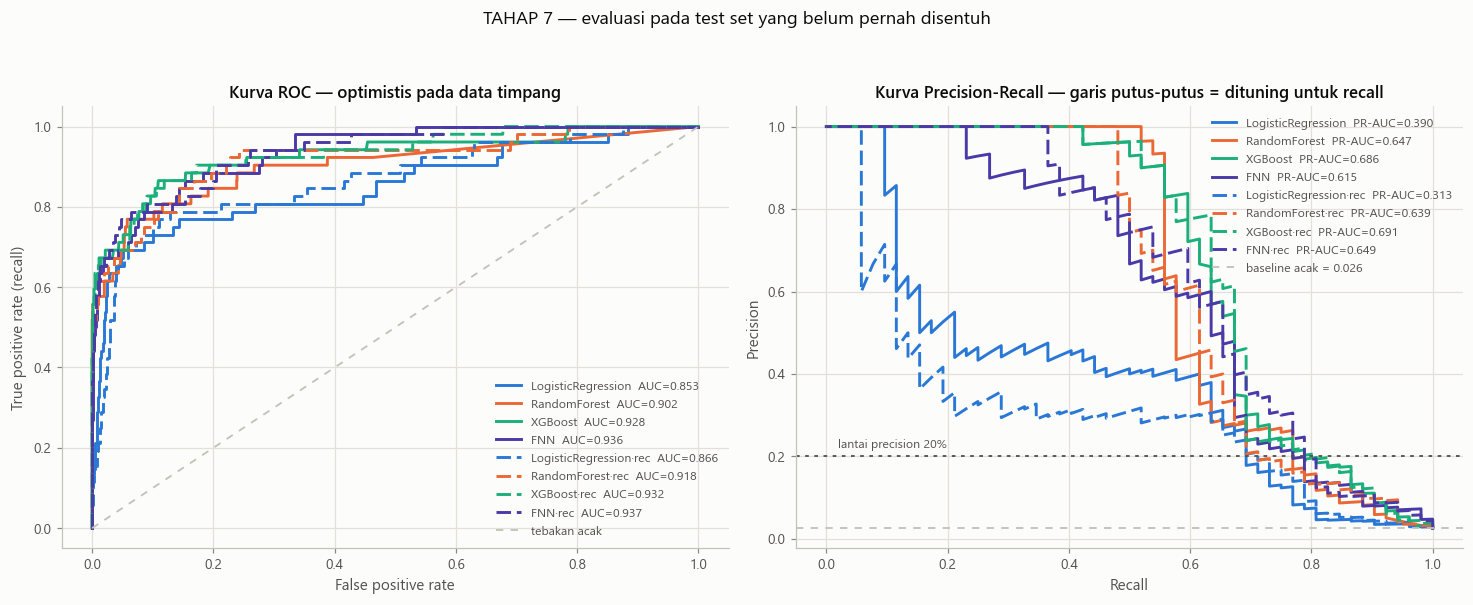

In [40]:
sec("7.6  Kurva ROC dan Precision-Recall, kedua keluarga model")
# Warna = model (identitas), gaya garis = objektif tuning (varian dari entitas
# yang sama). Jadi delapan kurva tetap muat di empat hue tanpa melanggar gate
# palet: solid = objektif PR-AUC, putus-putus = objektif precision.
GAYA_OBJ = {"PR-AUC": "-", "recall": (0, (5, 2))}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

ax = axes[0]
for nama in NAMA_EVAL:
    fpr, tpr, _ = roc_curve(y_te, proba_te[nama])
    v = hasil_te[(hasil_te.model == nama) & (hasil_te.titik == "threshold 0.5")]
    ax.plot(fpr, tpr, color=WARNA_MODEL[MODEL_DASAR[nama]],
            linestyle=GAYA_OBJ[OBJEKTIF[nama]], linewidth=1.9,
            label=f"{nama}  AUC={v.ROC_AUC.iloc[0]:.3f}")
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2, linestyle=(0, (4, 4)),
        label="tebakan acak")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.set_title("Kurva ROC — optimistis pada data timpang", fontsize=11)
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
for nama in NAMA_EVAL:
    prec, rec, _ = precision_recall_curve(y_te, proba_te[nama])
    v = hasil_te[(hasil_te.model == nama) & (hasil_te.titik == "threshold 0.5")]
    ax.plot(rec, prec, color=WARNA_MODEL[MODEL_DASAR[nama]],
            linestyle=GAYA_OBJ[OBJEKTIF[nama]], linewidth=1.9,
            label=f"{nama}  PR-AUC={v.PR_AUC.iloc[0]:.3f}")
ax.axhline(LANTAI_PRECISION, color=INK_2, linewidth=1.2, linestyle=(0, (2, 3)))
ax.annotate(f"lantai precision {LANTAI_PRECISION:.0%}", xy=(0.02, LANTAI_PRECISION),
            xytext=(0, 4), textcoords="offset points", fontsize=8,
            color=INK_2, va="bottom")
ax.axhline(y_te.mean(), color=AXIS, linewidth=1.2, linestyle=(0, (4, 4)),
           label=f"baseline acak = {y_te.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Kurva Precision-Recall — garis putus-putus = dituning "
             "untuk recall", fontsize=11)
ax.legend(loc="upper right", fontsize=8)
fig.suptitle("TAHAP 7 — evaluasi pada test set yang belum pernah disentuh",
             fontsize=12, color=INK, y=1.01)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


7.7  Confusion matrix: objektif PR-AUC vs objektif precision


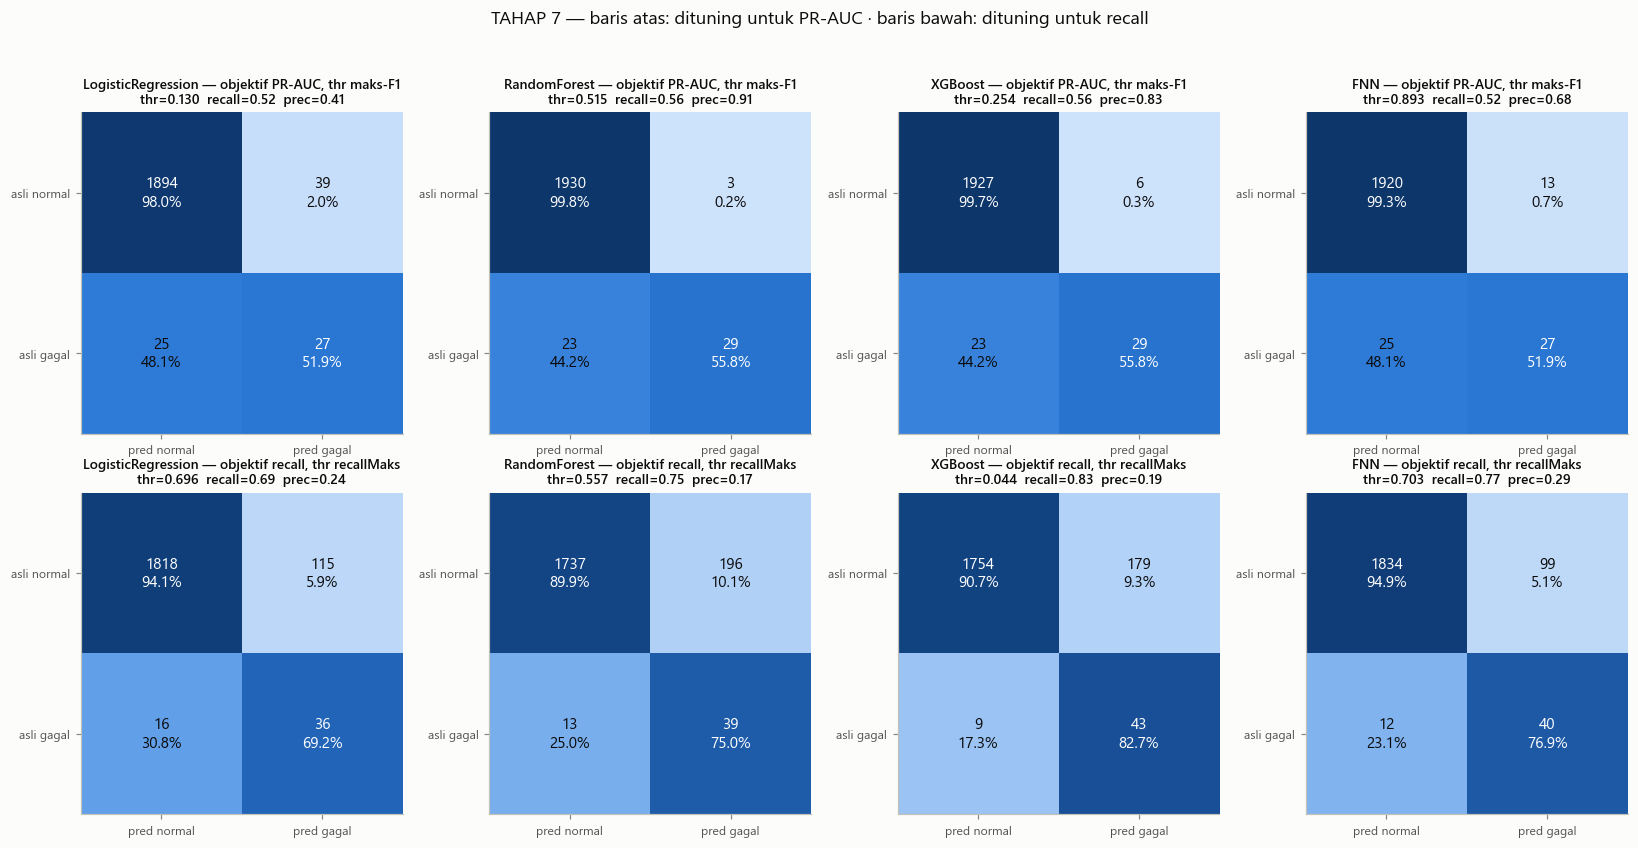

In [41]:
sec("7.7  Confusion matrix: objektif PR-AUC vs objektif precision")
TITIK_F1 = "maks F1 (dari OOF)"
TITIK_REC = f"recall maks @ precision>={LANTAI_PRECISION:.0%} (dari OOF)"

fig, axes = plt.subplots(2, len(NAMA_MODEL), figsize=(15, 7.6))
for kol, dasar in enumerate(NAMA_MODEL):
    for bar, (nm, titik, tag) in enumerate([
        (dasar, TITIK_F1, "objektif PR-AUC, thr maks-F1"),
        (f"{dasar}{SUFIKS_REC}", TITIK_REC,
         f"objektif recall, thr recallMaks"),
    ]):
        ax = axes[bar, kol]
        sub = hasil_te[(hasil_te.model == nm) & (hasil_te.titik == titik)]
        if sub.empty:                     # lantai precision tidak tercapai
            ax.text(0.5, 0.5, "lantai precision\ntidak tercapai", ha="center",
                    va="center", color=INK_2, fontsize=10)
            ax.set_axis_off()
            continue
        m = sub.iloc[0]
        cm = np.array([[m.TN, m.FP], [m.FN, m.TP]], dtype=int)
        ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap=CMAP_SEQ,
                  vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                frac = cm[i, j] / cm[i].sum()
                ax.text(j, i, f"{cm[i, j]}\n{frac:.1%}", ha="center",
                        va="center", fontsize=10,
                        color="#ffffff" if frac > 0.5 else INK)
        ax.set_xticks([0, 1], ["pred normal", "pred gagal"], fontsize=8)
        ax.set_yticks([0, 1], ["asli normal", "asli gagal"], fontsize=8)
        ax.set_title(f"{dasar} — {tag}\nthr={m.threshold:.3f}  "
                     f"recall={m.Recall:.2f}  prec={m.Precision:.2f}",
                     fontsize=9)
        ax.grid(False)
fig.suptitle("TAHAP 7 — baris atas: dituning untuk PR-AUC · "
             "baris bawah: dituning untuk recall", fontsize=12,
             color=INK, y=1.00)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [42]:
sec("7.8  Uji stabilitas: 5 seed berbeda")
print("random_state=42 tetap run utama yang dilaporkan. Empat seed lain hanya")
print("untuk mengukur varians: split ulang, fit ulang, threshold dicari ulang")
print("dari OOF seed itu sendiri, lalu dievaluasi di test seed itu.\n")

# Model final dipilih dari OOF TRAIN, bukan dari test: precision tertinggi yang
# biaya harapannya terendah pada rasio C_FN:C_FP yang dinyatakan.
#
# Kenapa kriterianya biaya, bukan lantai precision/recall: lantai adalah batas
# yang dipilih tangan, dan hasilnya sangat sensitif terhadap di mana batas itu
# ditaruh. Rasio biaya adalah besaran yang benar-benar dimiliki pabrik. Sekali
# rasionya dinyatakan, thresholdnya bukan lagi soal selera - dan kalau rasionya
# berubah, threshold baru bisa dihitung ulang tanpa melatih ulang model.
FINAL = thr["biaya_oof"].astype(float).idxmin()
print(f"Model final terpilih dari OOF train: {FINAL}")
print(f"  kriteria  : biaya harapan minimum pada C_FN:C_FP = {RASIO_BIAYA:.0f}:1")
print(f"  biaya OOF : {thr.loc[FINAL, 'biaya_oof']:.0f} "
      f"(satuan: setara berapa inspeksi sia-sia)")
print(f"  threshold : {thr.loc[FINAL, 'thr_biayaMin']:.4f}\n")

# Stabilitas dijalankan untuk keempat model objektif PR-AUC + model final,
# bukan kedelapan: FNN saja ~70 detik per seed, dan yang perlu dibuktikan
# stabil adalah kandidat yang benar-benar akan dipakai.
STAB_MODEL = list(dict.fromkeys(NAMA_MODEL + [FINAL]))
SEEDS = [42, 43, 44, 45, 46]
rows = []
for seed in SEEDS:
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, stratify=y,
                                      random_state=seed)
    skf_s = StratifiedKFold(5, shuffle=True, random_state=seed)
    for nama in STAB_MODEL:
        pipe = clone(EVAL[nama])
        for par in pipe.get_params():
            if par.endswith("random_state"):
                pipe.set_params(**{par: seed})
        p_oof = cross_val_predict(clone(pipe), Xa.to_numpy(), ya, cv=skf_s,
                                  method="predict_proba", n_jobs=1)[:, 1]
        # tiap keluarga dinilai pada aturan threshold-nya sendiri
        if nama == FINAL:
            t_pakai, _ = threshold_biaya_min(ya, p_oof, RASIO_BIAYA)
        else:
            t_pakai, _ = threshold_maks_f1(ya, p_oof)
        pipe.fit(Xa.to_numpy(), ya)
        rows.append({"seed": seed, "model": nama,
                     **metrik(yb, pipe.predict_proba(Xb.to_numpy())[:, 1], t_pakai)})
    print(f"  seed {seed} selesai")

stab = pd.DataFrame(rows)

METRIK_STAB = ["PR_AUC", "ROC_AUC", "Recall", "Precision", "F1", "Accuracy"]
ring = stab.groupby("model")[METRIK_STAB].agg(["mean", "std"])
tampil = pd.DataFrame({
    m: ring[(m, "mean")].round(4).astype(str) + " ± " +
       ring[(m, "std")].round(4).astype(str)
    for m in METRIK_STAB}).reindex(STAB_MODEL)
print(f"\nMean ± std lintas 5 seed ({FINAL} pada threshold biaya-minimum,")
print("sisanya pada threshold maks-F1 — tiap model pada aturannya sendiri):")
print(tampil.to_string())



7.8  Uji stabilitas: 5 seed berbeda
random_state=42 tetap run utama yang dilaporkan. Empat seed lain hanya
untuk mengukur varians: split ulang, fit ulang, threshold dicari ulang
dari OOF seed itu sendiri, lalu dievaluasi di test seed itu.

Model final terpilih dari OOF train: XGBoost
  kriteria  : biaya harapan minimum pada C_FN:C_FP = 10:1
  biaya OOF : 960 (satuan: setara berapa inspeksi sia-sia)
  threshold : 0.2544

  seed 42 selesai
  seed 43 selesai
  seed 44 selesai
  seed 45 selesai
  seed 46 selesai

Mean ± std lintas 5 seed (XGBoost pada threshold biaya-minimum,
sisanya pada threshold maks-F1 — tiap model pada aturannya sendiri):
                             PR_AUC          ROC_AUC           Recall        Precision               F1         Accuracy
model                                                                                                                   
LogisticRegression  0.3196 ± 0.0618  0.8629 ± 0.0347   0.4923 ± 0.057  0.3399 ± 0.0423   0.401 ± 0.0407   0.9

In [43]:
sec("7.9  Apakah HPO recall benar-benar menggeser kurva di TEST?")
print("Catatan: titik operasi yang DIKIRIM bukan titik ini, melainkan titik")
print("biaya-minimum di 7.10. Bagian ini hanya menguji apakah objektif HPO")
print("yang berbeda menghasilkan kurva PR yang berbeda - pertanyaan terpisah")
print("dari pertanyaan titik operasi mana yang dipakai.\n")
_a = hasil_te[hasil_te.titik == TITIK_F1].set_index("model")
_b = hasil_te[hasil_te.titik == TITIK_REC].set_index("model")
baris_c = []
for dasar in NAMA_MODEL:
    nm_p = f"{dasar}{SUFIKS_REC}"
    baris_c.append({
        "model": dasar,
        "prec_PRAUC_maksF1": _a.loc[dasar, "Precision"],
        "recall_PRAUC_maksF1": _a.loc[dasar, "Recall"],
        "FN_PRAUC": int(_a.loc[dasar, "FN"]),
        "FP_PRAUC": int(_a.loc[dasar, "FP"]),
        "prec_recHPO": _b.loc[nm_p, "Precision"] if nm_p in _b.index else np.nan,
        "recall_recHPO": _b.loc[nm_p, "Recall"] if nm_p in _b.index else np.nan,
        "FN_recHPO": int(_b.loc[nm_p, "FN"]) if nm_p in _b.index else -1,
        "FP_recHPO": int(_b.loc[nm_p, "FP"]) if nm_p in _b.index else -1,
    })
efek = pd.DataFrame(baris_c)
efek["delta_recall"] = efek.recall_recHPO - efek.recall_PRAUC_maksF1
efek["delta_precision"] = efek.prec_recHPO - efek.prec_PRAUC_maksF1
efek["kegagalan_tertangkap_tambahan"] = efek.FN_PRAUC - efek.FN_recHPO
efek["FP_tambahan"] = efek.FP_recHPO - efek.FP_PRAUC
print(efek.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("Pembandingnya jujur: kolom kiri adalah titik operasi terbaik menurut F1")
print("dari keluarga objektif PR-AUC, kolom kanan titik operasi recall dari")
print("keluarga objektif recall. Keduanya threshold-nya dari OOF train.")
print(f"Precision di kanan tidak boleh di bawah {LANTAI_PRECISION:.0%} - kalau ada")
print("yang di bawah, artinya lantai yang dijaga di CV tidak bertahan di test, dan")
print("itu harus dilaporkan sebagai kegagalan generalisasi, bukan disembunyikan.")
_bocor = efek[efek.prec_recHPO < LANTAI_PRECISION]
if len(_bocor):
    print(f"\nPERINGATAN: {len(_bocor)} model tidak mempertahankan lantai precision "
          f"di test: {list(_bocor.model)}")
else:
    print(f"\nSemua model keluarga recall mempertahankan precision >= "
          f"{LANTAI_PRECISION:.0%} di test.")


7.9  Apakah HPO recall benar-benar menggeser kurva di TEST?
Catatan: titik operasi yang DIKIRIM bukan titik ini, melainkan titik
biaya-minimum di 7.10. Bagian ini hanya menguji apakah objektif HPO
yang berbeda menghasilkan kurva PR yang berbeda - pertanyaan terpisah
dari pertanyaan titik operasi mana yang dipakai.

             model  prec_PRAUC_maksF1  recall_PRAUC_maksF1  FN_PRAUC  FP_PRAUC  prec_recHPO  recall_recHPO  FN_recHPO  FP_recHPO  delta_recall  delta_precision  kegagalan_tertangkap_tambahan  FP_tambahan
LogisticRegression             0.4091               0.5192        25        39       0.2384         0.6923         16        115        0.1731          -0.1707                              9           76
      RandomForest             0.9062               0.5577        23         3       0.1660         0.7500         13        196        0.1923          -0.7403                             10          193
           XGBoost             0.8286               0.5577        23  

In [44]:
sec(f"7.10  Titik operasi berbasis biaya — sensitivitas terhadap rasio C_FN:C_FP")
print("Recall dan precision itu satu kurva, bukan dua tombol. Yang menentukan")
print("titik potongnya adalah rasio biaya, dan itu besaran pabrik - bukan")
print("besaran statistik. Tabel ini memetakan keduanya.\n")
print(f"Model: {FINAL}. Threshold tiap baris DITURUNKAN DARI OOF TRAIN pada")
print("rasio itu, lalu diterapkan ke test - jadi tidak ada yang dicuri dari test.\n")

p_fin_oof, p_fin_te = oof[FINAL], proba_te[FINAL]
baris_s = []
for r in [1, 2, 5, 10, 20, 30, 50, 100]:
    t_r, _ = threshold_biaya_min(y_tr, p_fin_oof, float(r))
    m = metrik(y_te, p_fin_te, t_r)
    baris_s.append({
        "C_FN:C_FP": f"{r}:1", "threshold": t_r,
        "Recall": m["Recall"], "Precision": m["Precision"],
        "TP": m["TP"], "FP": m["FP"], "FN": m["FN"],
        "false_alarm_per_1000": m["false_alarm_per_1000"],
        "kegagalan_lolos_per_1000": m["missed_per_1000"],
        "biaya_test": r * m["FN"] + m["FP"],
    })
sens = pd.DataFrame(baris_s)
print(sens.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

_dipakai = sens[sens["C_FN:C_FP"] == f"{RASIO_BIAYA:.0f}:1"].iloc[0]
print()
print(f"ASUMSI YANG DIPAKAI: {RASIO_BIAYA:.0f}:1 — satu unplanned downtime")
print(f"dianggap semahal {RASIO_BIAYA:.0f} inspeksi sia-sia. Pada rasio itu:")
print(f"  recall {_dipakai.Recall:.1%}, precision {_dipakai.Precision:.1%}, "
      f"{_dipakai.false_alarm_per_1000:.1f} false alarm dan "
      f"{_dipakai.kegagalan_lolos_per_1000:.1f} kegagalan lolos per 1.000 unit.")
print()
print("Kalau rasio biaya di pabrikmu berbeda, threshold-nya tinggal diambil dari")
print("baris lain di tabel ini. Model TIDAK perlu dilatih ulang - rankingnya")
print("tidak berubah, hanya titik potongnya.")
print()
print("Kenapa rasio ini yang dipilih sebagai default: pada 5:1 sampai ~15:1")
print("threshold optimalnya nyaris sama (plateau), jadi pilihan ini tahan")
print("terhadap ketidakpastian estimasi biaya. Titik recall-maksimum yang")
print("sebelumnya dipakai baru jadi optimal kalau rasionya >= 30:1.")
print()
print("Satu risiko yang TIDAK muncul di tabel mana pun: alarm fatigue. Pada")
print("precision rendah, operator berhenti mempercayai alarm dan mulai")
print("mengabaikannya - termasuk yang benar. Recall efektif di lapangan lalu")
print("runtuh jauh di bawah angka di sini. Itu alasan tambahan tidak mengejar")
print("recall setinggi mungkin hanya karena metriknya terlihat bagus.")


7.10  Titik operasi berbasis biaya — sensitivitas terhadap rasio C_FN:C_FP
Recall dan precision itu satu kurva, bukan dua tombol. Yang menentukan
titik potongnya adalah rasio biaya, dan itu besaran pabrik - bukan
besaran statistik. Tabel ini memetakan keduanya.

Model: XGBoost. Threshold tiap baris DITURUNKAN DARI OOF TRAIN pada
rasio itu, lalu diterapkan ke test - jadi tidak ada yang dicuri dari test.

C_FN:C_FP  threshold  Recall  Precision  TP  FP  FN  false_alarm_per_1000  kegagalan_lolos_per_1000  biaya_test
      1:1     0.3862  0.5577     0.8788  29   4  23                2.0151                   11.5869          27
      2:1     0.2544  0.5577     0.8286  29   6  23                3.0227                   11.5869          52
      5:1     0.2544  0.5577     0.8286  29   6  23                3.0227                   11.5869         121
     10:1     0.2544  0.5577     0.8286  29   6  23                3.0227                   11.5869         236
     20:1     0.0247  0.8654    

In [45]:
sec("KESIMPULAN TAHAP 7")
pr_te = hasil_te[hasil_te.titik == "threshold 0.5"].set_index("model").PR_AUC
JUARA = pr_te.idxmax()
print(f"- PR-AUC test tertinggi: {JUARA} = {pr_te.max():.4f} "
      f"(baseline acak {y_te.mean():.4f} -> {pr_te.max() / y_te.mean():.1f}x lebih baik)")
# Juara PR-AUC test belum tentu ikut uji stabilitas: STAB_MODEL hanya memuat
# keempat model dasar + FINAL. Kalau juaranya varian objektif recall, yang
# dilaporkan adalah model dasarnya, dan itu dinyatakan eksplisit.
_stab = JUARA if JUARA in ring.index else MODEL_DASAR[JUARA]
print(f"- Lintas 5 seed, {_stab}: PR-AUC {ring.loc[_stab, ('PR_AUC', 'mean')]:.4f} "
      f"+-{ring.loc[_stab, ('PR_AUC', 'std')]:.4f}, "
      f"Recall {ring.loc[_stab, ('Recall', 'mean')]:.4f} "
      f"+-{ring.loc[_stab, ('Recall', 'std')]:.4f}")
if _stab != JUARA:
    print(f"  ({JUARA} sendiri tidak masuk uji stabilitas; angka di atas untuk "
          f"varian objektif PR-AUC dari model yang sama.)")
print()
TITIK_BIAYA = f"biaya minimum {RASIO_BIAYA:.0f}:1 (dari OOF)"
_mf = hasil_te[(hasil_te.model == FINAL) & (hasil_te.titik == TITIK_BIAYA)].iloc[0]
print(f"- MODEL FINAL (biaya harapan minimum di OOF train): {FINAL}")
print(f"  di threshold {_mf.threshold:.4f} -> precision {_mf.Precision:.1%}, "
      f"recall {_mf.Recall:.1%}, {int(_mf.FP)} false positive, {int(_mf.FN)} lolos")
print(f"- Rata-rata perubahan recall berkat HPO recall: "
      f"{efek.delta_recall.mean():+.4f}, dengan precision "
      f"{efek.delta_precision.mean():+.4f}")
print(f"- Hanya {int(y_te.sum())} kegagalan di test: satu-dua kasus beda sudah")
print(f"  menggeser recall ~{1 / y_te.sum() * 100:.1f} poin persen.")


KESIMPULAN TAHAP 7
- PR-AUC test tertinggi: XGBoost·rec = 0.6913 (baseline acak 0.0262 -> 26.4x lebih baik)
- Lintas 5 seed, XGBoost: PR-AUC 0.6715 +-0.0550, Recall 0.6231 +-0.0586
  (XGBoost·rec sendiri tidak masuk uji stabilitas; angka di atas untuk varian objektif PR-AUC dari model yang sama.)

- MODEL FINAL (biaya harapan minimum di OOF train): XGBoost
  di threshold 0.2544 -> precision 82.9%, recall 55.8%, 6 false positive, 23 lolos
- Rata-rata perubahan recall berkat HPO recall: +0.2212, dengan precision -0.4833
- Hanya 52 kegagalan di test: satu-dua kasus beda sudah
  menggeser recall ~1.9 poin persen.


---
## TAHAP 8 — Explainability

SHAP dibandingkan berdampingan dengan permutation importance dan impurity
importance. Impurity importance **tidak** dipakai sendirian karena bias
terhadap fitur berkardinalitas tinggi.

In [47]:
TREE_EVAL = [n for n in NAMA_EVAL
             if MODEL_DASAR[n] in ("RandomForest", "XGBoost")]
# Yang dijelaskan adalah model yang benar-benar akan dipakai, kalau ia model
# tree. Kalau bukan, jatuh ke model tree terbaik - TreeExplainer tidak berlaku
# untuk FNN maupun regresi logistik.
TERBAIK = FINAL if FINAL in TREE_EVAL else pr_te.loc[TREE_EVAL].idxmax()

sec(f"8.1  Model yang dijelaskan: {TERBAIK}")
print(f"Ini model final (objektif: {OBJEKTIF[TERBAIK]}). "
      f"PR-AUC test: {pr_te.loc[TERBAIK]:.4f}")
print(f"Peringkat PR-AUC seluruh model:")
for k, v in pr_te.sort_values(ascending=False).items():
    print(f"    {k:24s} {v:.4f}")
if FINAL not in TREE_EVAL:
    print(f"\nCatatan: model final {FINAL} bukan model tree, jadi {TERBAIK} "
          f"yang dijelaskan di sini.")

pipe_shap = EVAL[TERBAIK]
scaler_shap = pipe_shap.named_steps["scaler"]
model_shap = pipe_shap.named_steps["model"]
X_te_scaled = scaler_shap.transform(X_te)

sec("8.2  Menghitung SHAP values (TreeExplainer)")
explainer = shap.TreeExplainer(model_shap)
sv = explainer.shap_values(X_te_scaled)
if isinstance(sv, list):      # sebagian versi mengembalikan list per kelas
    sv = sv[1]
if sv.ndim == 3:              # bentuk (n, fitur, kelas)
    sv = sv[:, :, 1]
base_val = explainer.expected_value
base_val = base_val[1] if np.ndim(base_val) > 0 else base_val
print(f"Bentuk SHAP values : {sv.shape}")
print(f"Nilai dasar (base) : {base_val:.4f}")

# Ditampilkan memakai NILAI ASLI, bukan nilai terskala: StandardScaler adalah
# transformasi afin monoton per fitur, jadi SHAP value-nya identik sementara
# sumbu dependence plot jadi terbaca dalam satuan fisik.
expl = shap.Explanation(values=sv, base_values=np.full(len(sv), base_val),
                        data=X_te, feature_names=FEATURES)

mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(
    ascending=False)
print("\nmean |SHAP| per fitur:")
print(mean_abs.to_string(float_format=lambda v: f"{v:.5f}"))



8.1  Model yang dijelaskan: XGBoost
Ini model final (objektif: PR-AUC). PR-AUC test: 0.6857
Peringkat PR-AUC seluruh model:
    XGBoost·rec              0.6913
    XGBoost                  0.6857
    FNN·rec                  0.6487
    RandomForest             0.6475
    RandomForest·rec         0.6392
    FNN                      0.6147
    LogisticRegression       0.3900
    LogisticRegression·rec   0.3126

8.2  Menghitung SHAP values (TreeExplainer)
Bentuk SHAP values : (1985, 9)
Nilai dasar (base) : -3.9724

mean |SHAP| per fitur:
rpm                   1.32551
tool_wear_min         0.40687
Temp_diff             0.17973
Wear_x_rpm            0.17312
Temp_ratio            0.16251
Thermal_wear_load     0.11817
proc_temp_K           0.08113
Cooling_margin_rate   0.08072
air_temp_K            0.07700



8.3  SHAP summary plot (beeswarm)


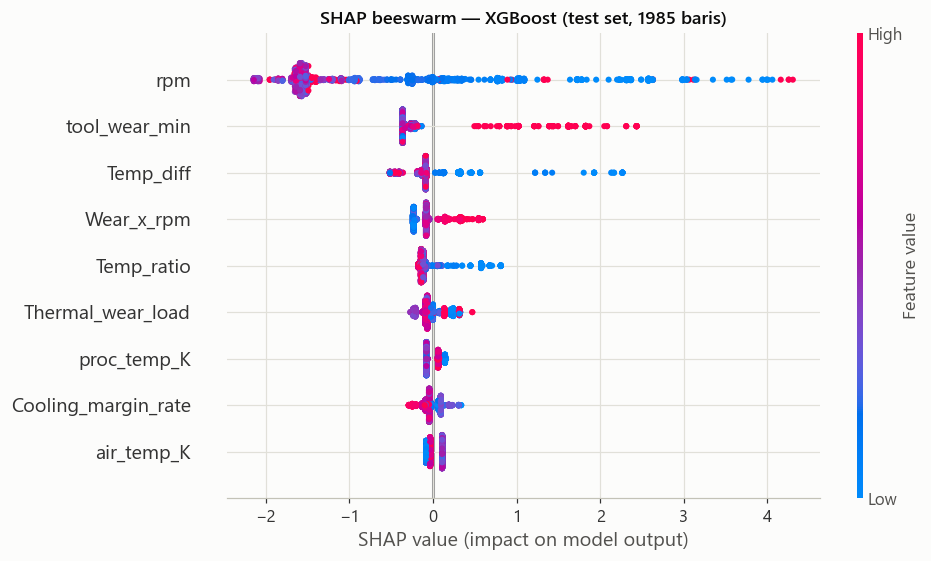

In [48]:
sec("8.3  SHAP summary plot (beeswarm)")
plt.figure(figsize=(9, 5.2))
shap.summary_plot(sv, pd.DataFrame(X_te, columns=FEATURES),
                  feature_names=FEATURES, show=False, plot_size=None)
plt.title(f"SHAP beeswarm — {TERBAIK} (test set, {len(X_te)} baris)",
          fontsize=12, color=INK)
plt.tight_layout()
plt.show()


8.4  SHAP bar plot


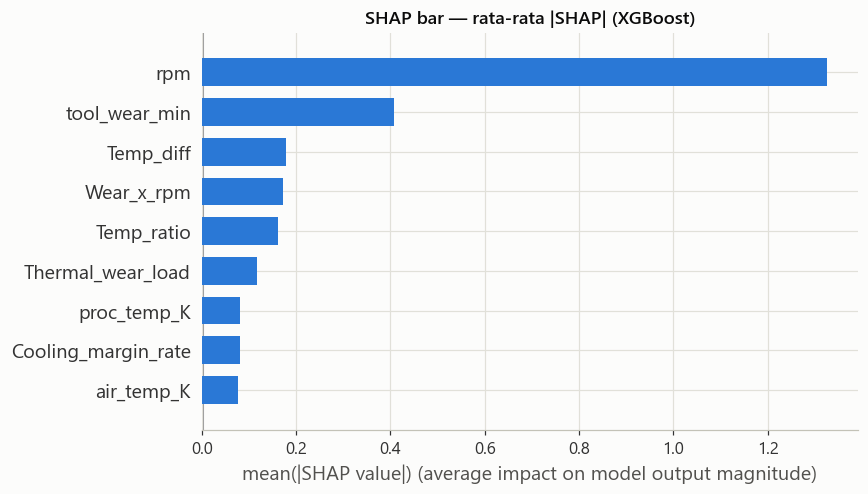

In [49]:
sec("8.4  SHAP bar plot")
plt.figure(figsize=(8, 4.6))
shap.summary_plot(sv, pd.DataFrame(X_te, columns=FEATURES),
                  feature_names=FEATURES, plot_type="bar", show=False,
                  plot_size=None, color=SERI[0])
plt.title(f"SHAP bar — rata-rata |SHAP| ({TERBAIK})", fontsize=12, color=INK)
plt.tight_layout()
plt.show()


8.5  Dependence plot 3 fitur teratas
Tiga fitur teratas: ['rpm', 'tool_wear_min', 'Temp_diff']


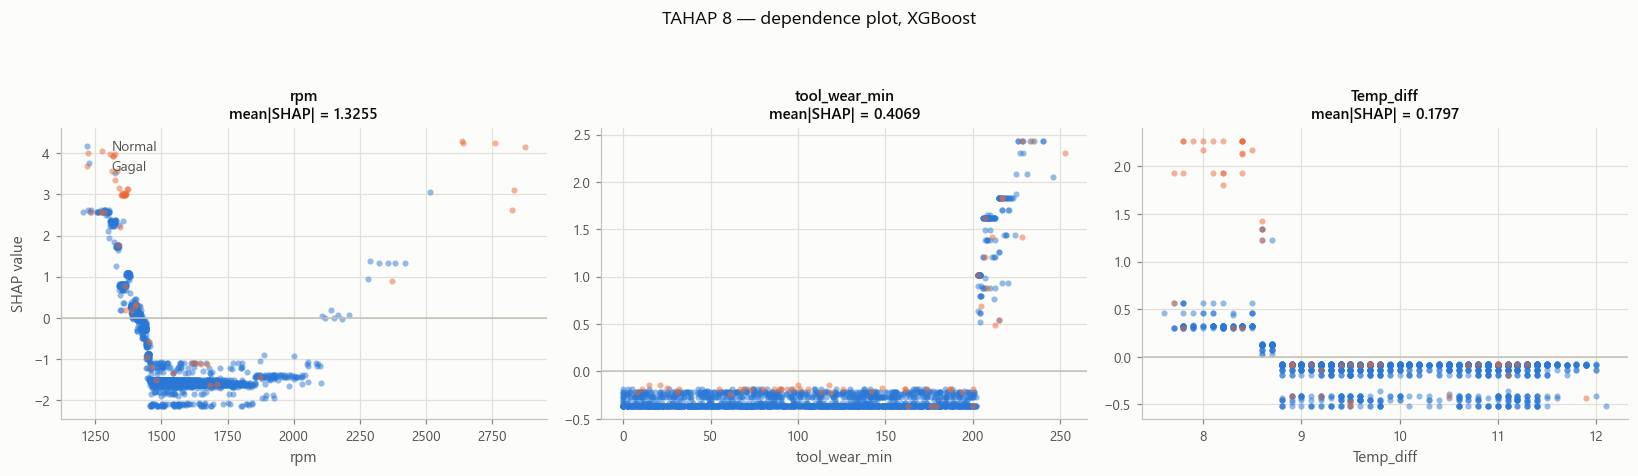

In [50]:
sec("8.5  Dependence plot 3 fitur teratas")
top3 = list(mean_abs.index[:3])
print("Tiga fitur teratas:", top3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, f in zip(axes, top3):
    j = FEATURES.index(f)
    # diwarnai per kelas asli (identitas), bukan gradien magnitudo
    for kelas, label in [(0, "Normal"), (1, "Gagal")]:
        m_ = y_te == kelas
        ax.scatter(X_te[m_, j], sv[m_, j], s=16, alpha=0.5, linewidths=0,
                   color=WARNA_KELAS[kelas], label=label)
    ax.axhline(0, color=AXIS, linewidth=1)
    ax.set_xlabel(f)
    ax.set_ylabel("SHAP value" if f == top3[0] else "")
    ax.set_title(f"{f}\nmean|SHAP| = {mean_abs[f]:.4f}", fontsize=10)
axes[0].legend(loc="upper left")
fig.suptitle(f"TAHAP 8 — dependence plot, {TERBAIK}", fontsize=12, color=INK, y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


8.6  Waterfall untuk kasus kegagalan individual

  terdeteksi paling yakin: baris test #1752, probabilitas 0.9761
      rpm                    =     1324.000   SHAP +3.3490
      Temp_diff              =        8.200   SHAP +1.8033
      tool_wear_min          =      228.000   SHAP +1.4207
      Temp_ratio             =        1.027   SHAP +0.6827

  nyaris lolos (probabilitas terendah): baris test #102, probabilitas 0.0018
      rpm                    =     1710.000   SHAP -1.6120
      tool_wear_min          =      163.000   SHAP -0.3642
      Temp_ratio             =        1.038   SHAP -0.1413
      Wear_x_rpm             =   278730.000   SHAP +0.1412


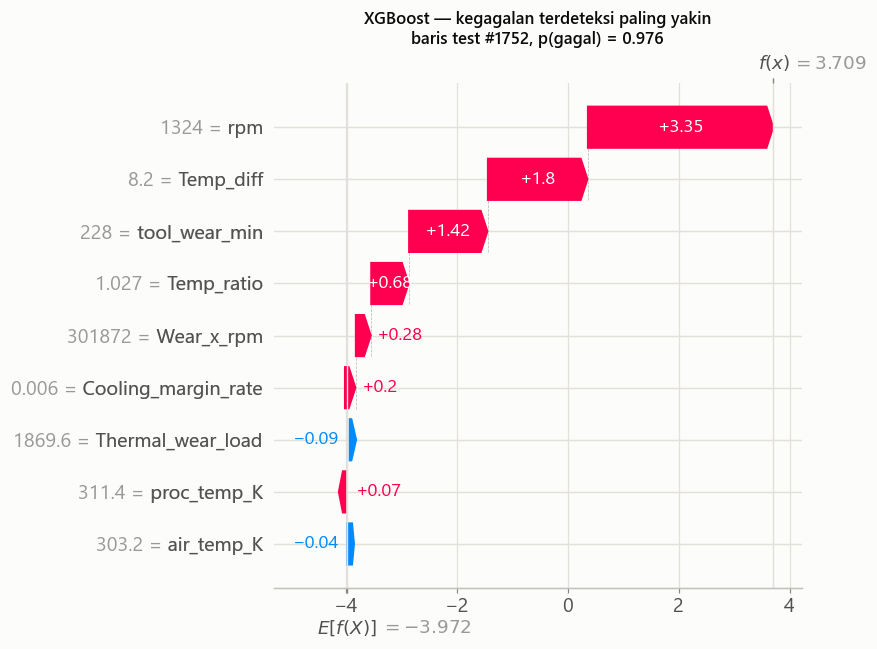

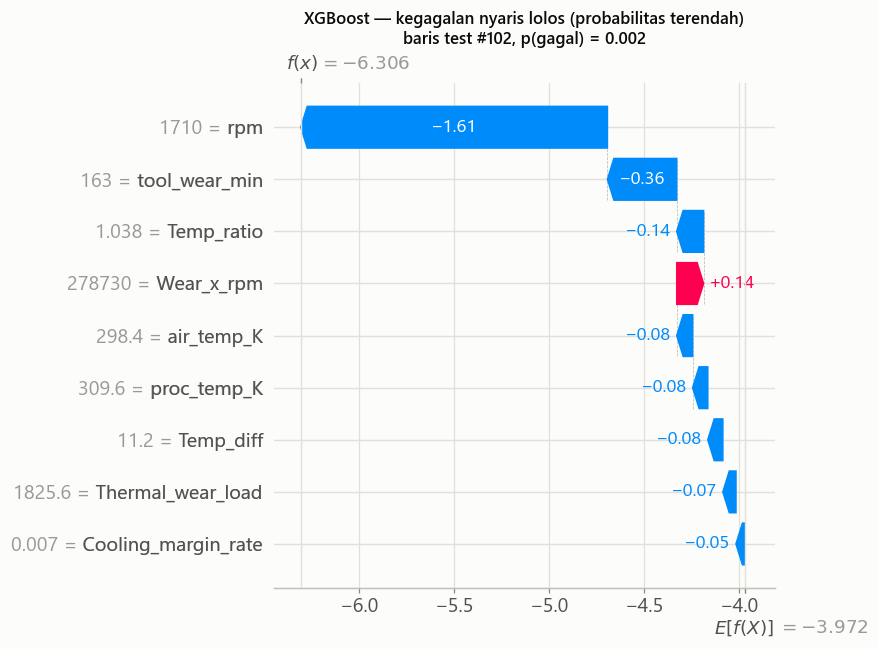

In [51]:
sec("8.6  Waterfall untuk kasus kegagalan individual")
proba_shap = pipe_shap.predict_proba(X_te)[:, 1]
idx_gagal = np.where(y_te == 1)[0]
urut = idx_gagal[np.argsort(proba_shap[idx_gagal])]
kasus = {"terdeteksi paling yakin": int(urut[-1]),
         "nyaris lolos (probabilitas terendah)": int(urut[0])}
for label, i in kasus.items():
    print(f"\n  {label}: baris test #{i}, probabilitas {proba_shap[i]:.4f}")
    for f, v, s in sorted(zip(FEATURES, X_te[i], sv[i]), key=lambda t: -abs(t[2]))[:4]:
        print(f"      {f:22s} = {v:12.3f}   SHAP {s:+.4f}")

for label, i in kasus.items():
    plt.figure(figsize=(8.5, 4.6))
    shap.plots.waterfall(expl[i], max_display=10, show=False)
    plt.title(f"{TERBAIK} — kegagalan {label}\n"
              f"baris test #{i}, p(gagal) = {proba_shap[i]:.3f}",
              fontsize=11, color=INK)
    plt.tight_layout()
    plt.show()

In [52]:
sec("8.7  SHAP vs permutation importance vs impurity importance")
perm = permutation_importance(pipe_shap, X_te, y_te, scoring="average_precision",
                              n_repeats=20, random_state=RS, n_jobs=-1)
imp = pd.DataFrame({
    "mean_abs_SHAP": mean_abs,
    "permutation_dPR_AUC": pd.Series(perm.importances_mean, index=FEATURES),
    "permutation_std": pd.Series(perm.importances_std, index=FEATURES),
    "impurity": pd.Series(model_shap.feature_importances_, index=FEATURES),
})
for k in ["mean_abs_SHAP", "permutation_dPR_AUC", "impurity"]:
    imp[f"rank_{k}"] = imp[k].rank(ascending=False).astype(int)
imp = imp.sort_values("mean_abs_SHAP", ascending=False)
print(imp.to_string(float_format=lambda v: f"{v:.5f}"))

print()
print("Kenapa impurity importance tidak boleh jadi sandaran tunggal:")
print("  Ia menghitung total penurunan impurity saat sebuah fitur dipakai untuk")
print("  split. Fitur berkardinalitas tinggi punya jauh lebih banyak titik split")
print("  kandidat, jadi lebih sering terpilih secara kebetulan dan skornya")
print("  menggelembung. Di sini kardinalitasnya sangat timpang:")
kard = pd.Series({f: len(np.unique(X_tr[:, i])) for i, f in enumerate(FEATURES)})
print(pd.DataFrame({"n_nilai_unik": kard, "impurity": imp.impurity,
                    "rank_impurity": imp.rank_impurity,
                    "rank_SHAP": imp.rank_mean_abs_SHAP}).sort_values(
    "n_nilai_unik", ascending=False).to_string())
print()
print("  Selain itu impurity dihitung dari data TRAIN dan tidak pernah menguji")
print("  apakah fitur itu berguna di data baru. Permutation importance mengukur")
print("  penurunan PR-AUC nyata di TEST saat fitur diacak - pertanyaan berbeda")
print("  dan lebih relevan secara operasional.")

selisih_rank = (imp.rank_impurity - imp.rank_mean_abs_SHAP).abs()
kard_tertinggi = kard.idxmax()
print()
print("APA YANG SEBENARNYA TERJADI DI DATASET INI (bukan klaim buku teks):")
print(f"  Selisih peringkat impurity vs SHAP terbesar hanya {selisih_rank.max()} "
      f"posisi ({selisih_rank.idxmax()}).")
print(f"  Fitur berkardinalitas tertinggi, {kard_tertinggi} "
      f"({kard[kard_tertinggi]} nilai unik), justru duduk di peringkat "
      f"{int(imp.loc[kard_tertinggi, 'rank_impurity'])} menurut impurity")
print(f"  dan {int(imp.loc[kard_tertinggi, 'rank_mean_abs_SHAP'])} menurut SHAP - "
      "tidak menggelembung.")
print("  Jadi pada dataset ini bias kardinalitas TIDAK terwujud, dan ketiga")
print("  ukuran sepakat soal fitur mana yang penting. Itu temuan yang menguatkan,")
print("  bukan alasan untuk berhenti mengecek: yang membuat kita tahu bias itu")
print("  tidak terjadi justru karena ketiganya dihitung dan dibandingkan.")


8.7  SHAP vs permutation importance vs impurity importance
                     mean_abs_SHAP  permutation_dPR_AUC  permutation_std  impurity  rank_mean_abs_SHAP  rank_permutation_dPR_AUC  rank_impurity
rpm                        1.32551              0.59963          0.01832   0.10883                   1                         1              2
tool_wear_min              0.40687              0.04918          0.00695   0.07107                   2                         3              3
Temp_diff                  0.17973              0.43743          0.03142   0.63376                   3                         2              1
Wear_x_rpm                 0.17312              0.01236          0.00805   0.03503                   4                         4              5
Temp_ratio                 0.16251              0.00753          0.00904   0.03547                   5                         5              4
Thermal_wear_load          0.11817              0.00196          0.00615   0

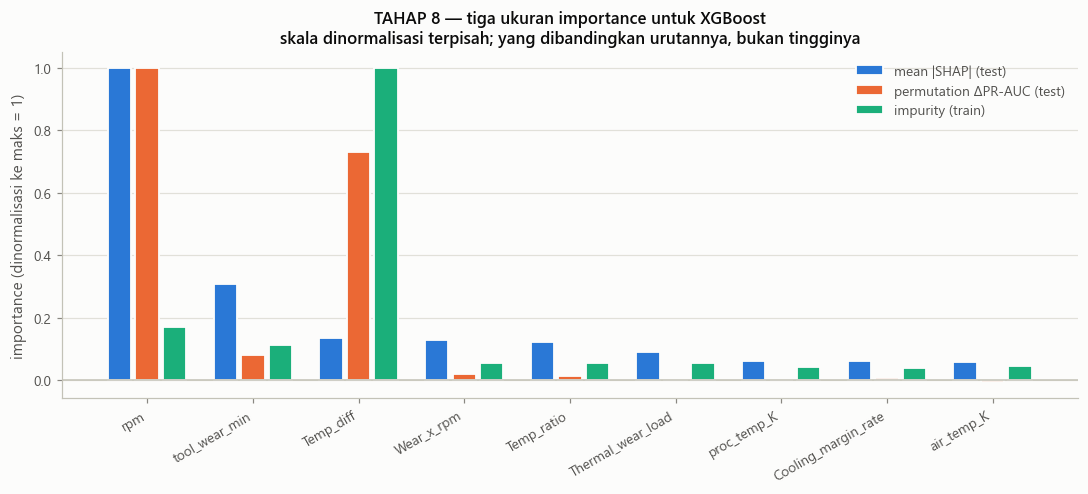

In [53]:
fig, ax = plt.subplots(figsize=(10, 4.6))
xs = np.arange(len(imp))
lebar = 0.26
for k, (kolom, label) in enumerate([
    ("mean_abs_SHAP", "mean |SHAP| (test)"),
    ("permutation_dPR_AUC", "permutation ΔPR-AUC (test)"),
    ("impurity", "impurity (train)"),
]):
    ax.bar(xs + (k - 1) * lebar, imp[kolom] / imp[kolom].abs().max(),
           lebar * 0.85, label=label, color=SERI[k], edgecolor=SURFACE,
           linewidth=1.2)
ax.set_xticks(xs, imp.index, rotation=30, ha="right")
ax.set_ylabel("importance (dinormalisasi ke maks = 1)")
ax.axhline(0, color=AXIS, linewidth=1)
ax.grid(axis="x", visible=False)
ax.legend()
ax.set_title(f"TAHAP 8 — tiga ukuran importance untuk {TERBAIK}\n"
             "skala dinormalisasi terpisah; yang dibandingkan urutannya, "
             "bukan tingginya", fontsize=11)
fig.tight_layout()
plt.show()

In [54]:
sec("8.8  Interpretasi fisik")
print(f"Tiga fitur teratas menurut SHAP: {top3}")
print(f"Tiga teratas menurut permutation importance: "
      f"{list(imp.sort_values('permutation_dPR_AUC', ascending=False).index[:3])}")
print()
print("Mekanisme degradasi yang MASIH bisa dibaca dari feature set ini:")
print("  - Heat dissipation: selisih suhu proses-udara mengecil sekaligus putaran")
print("    rendah. Temp_diff dan Cooling_margin_rate memang dibuat untuk ini.")
print("  - Tool wear: keausan pahat terakumulasi; tool_wear_min, Wear_x_rpm, dan")
print("    Thermal_wear_load menargetkan mekanisme ini.")
print()
print("SOAL KLAIM 'DOMINASI TOOL WEAR':")
print(f"  tool_wear_min peringkat {int(imp.loc['tool_wear_min', 'rank_mean_abs_SHAP'])} menurut SHAP "
      f"dan {int(imp.loc['tool_wear_min', 'rank_permutation_dPR_AUC'])} menurut permutasi.")
_puncak = mean_abs.index[0]
print(f"  Yang memuncaki keduanya adalah {_puncak} "
      f"(mean|SHAP| {mean_abs[_puncak]:.3f}, "
      f"permutasi {imp.loc[_puncak, 'permutation_dPR_AUC']:.3f} PR-AUC).")
print()
print("YANG TIDAK BISA DIUJI DI SINI:")
print("  Mekanisme yang variabel penentunya tidak diukur di dataset ini - beban")
print("  torsi dan daya adalah contoh yang paling jelas - tidak punya jejak")
print("  apa pun di antara sembilan fitur ini. Kegagalan jenis itu, kalau ada")
print("  di dalam label, hanya bisa ditebak lewat korelasi tak langsung.")
print("  Konsekuensinya ceiling recall studi ini ditekan secara struktural, dan")
print("  besarnya TIDAK dapat diukur karena dataset tidak memuat label mode.")
print("  Itu keterbatasan yang dilaporkan, bukan yang bisa dikuantifikasi.")



8.8  Interpretasi fisik
Tiga fitur teratas menurut SHAP: ['rpm', 'tool_wear_min', 'Temp_diff']
Tiga teratas menurut permutation importance: ['rpm', 'Temp_diff', 'tool_wear_min']

Mekanisme degradasi yang MASIH bisa dibaca dari feature set ini:
  - Heat dissipation: selisih suhu proses-udara mengecil sekaligus putaran
    rendah. Temp_diff dan Cooling_margin_rate memang dibuat untuk ini.
  - Tool wear: keausan pahat terakumulasi; tool_wear_min, Wear_x_rpm, dan
    Thermal_wear_load menargetkan mekanisme ini.

SOAL KLAIM 'DOMINASI TOOL WEAR':
  tool_wear_min peringkat 2 menurut SHAP dan 3 menurut permutasi.
  Yang memuncaki keduanya adalah rpm (mean|SHAP| 1.326, permutasi 0.600 PR-AUC).

YANG TIDAK BISA DIUJI DI SINI:
  Mekanisme yang variabel penentunya tidak diukur di dataset ini - beban
  torsi dan daya adalah contoh yang paling jelas - tidak punya jejak
  apa pun di antara sembilan fitur ini. Kegagalan jenis itu, kalau ada
  di dalam label, hanya bisa ditebak lewat korelasi tak lang

In [55]:
sec("KESIMPULAN TAHAP 8")
print(f"- Model dijelaskan   : {TERBAIK}, PR-AUC test {pr_te.loc[TERBAIK]:.4f}")
print(f"- Peringkat SHAP     : {list(mean_abs.index[:5])}")
print(f"- Peringkat permutasi: "
      f"{list(imp.sort_values('permutation_dPR_AUC', ascending=False).index[:5])}")
print(f"- Peringkat impurity : {list(imp.sort_values('impurity', ascending=False).index[:5])}")
print("- Ketiganya dilaporkan berdampingan; impurity tidak dipakai sendirian.")


KESIMPULAN TAHAP 8
- Model dijelaskan   : XGBoost, PR-AUC test 0.6857
- Peringkat SHAP     : ['rpm', 'tool_wear_min', 'Temp_diff', 'Wear_x_rpm', 'Temp_ratio']
- Peringkat permutasi: ['rpm', 'Temp_diff', 'tool_wear_min', 'Wear_x_rpm', 'Temp_ratio']
- Peringkat impurity : ['Temp_diff', 'rpm', 'tool_wear_min', 'Temp_ratio', 'Wear_x_rpm']
- Ketiganya dilaporkan berdampingan; impurity tidak dipakai sendirian.


---
## TAHAP 9 — Pelaporan

Tabel perbandingan final, rekomendasi titik operasi, lalu penyimpanan model
ke `model_klasifikasi_failure.pkl`. Notebook ini tidak menulis file laporan
maupun artefak tabel/gambar — satu-satunya keluaran berkas adalah pickle itu.

In [57]:
sec("9.1  Tabel perbandingan final: model x strategi x metrik")
final = cv5[["model", "strategi", "PR_AUC", "ROC_AUC", "Recall", "Precision",
             "F1", "Accuracy"]].copy()
final.columns = ["model", "strategi", "PR-AUC", "ROC-AUC", "Recall", "Precision",
                 "F1", "Accuracy"]
final.insert(2, "sumber", "CV 5-fold train (untuned, thr 0.5)")

baris_tuned = [{"model": r["model"],
                "strategi": f"tuned: {r['imbalance']}",
                "sumber": "CV 5-fold train (tuned)", "PR-AUC": r["PR_AUC_cv"],
                "ROC-AUC": np.nan, "Recall": np.nan, "Precision": np.nan,
                "F1": np.nan, "Accuracy": np.nan}
               for _, r in tune.iterrows()]

baris_test = [{"model": r["model"], "strategi": f"tuned @ {r['titik']}",
               "sumber": "TEST set", "PR-AUC": r["PR_AUC"], "ROC-AUC": r["ROC_AUC"],
               "Recall": r["Recall"], "Precision": r["Precision"], "F1": r["F1"],
               "Accuracy": r["Accuracy"]}
              for _, r in hasil_te.iterrows()]

final = pd.concat([final, pd.DataFrame(baris_tuned), pd.DataFrame(baris_test)],
                  ignore_index=True)
print(final.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


9.1  Tabel perbandingan final: model x strategi x metrik
                 model                                        strategi                             sumber  PR-AUC  ROC-AUC  Recall  Precision     F1  Accuracy
    LogisticRegression                                        baseline CV 5-fold train (untuned, thr 0.5)  0.2814   0.8446  0.0333     0.5167 0.0622    0.9739
    LogisticRegression                                    class_weight CV 5-fold train (untuned, thr 0.5)  0.2206   0.8687  0.8228     0.0883 0.1594    0.7711
    LogisticRegression                                           SMOTE CV 5-fold train (untuned, thr 0.5)  0.2120   0.8675  0.8228     0.0932 0.1674    0.7839
    LogisticRegression                                      SMOTETomek CV 5-fold train (untuned, thr 0.5)  0.2137   0.8674  0.8228     0.0933 0.1676    0.7842
    LogisticRegression                                          Jitter CV 5-fold train (untuned, thr 0.5)  0.2193   0.8692  0.8228     0.0894 0.161

In [58]:
sec("9.2  Rekomendasi operasional pada threshold terpilih")
ops = []
for nama in NAMA_EVAL:
    for label, kolom in [("maks F1", "thr_maksF1"),
                         ("recall>=90%", "thr_recall90"),
                         (f"recall maks @precision>={LANTAI_PRECISION:.0%}", "thr_recallMaks"),
                         (f"biaya minimum {RASIO_BIAYA:.0f}:1", "thr_biayaMin")]:
        t = thr.loc[nama, kolom]
        if pd.isna(t):
            continue
        m = metrik(y_te, proba_te[nama], t)
        ops.append({"model": nama, "kriteria_threshold": label, "threshold": t,
                    "recall": m["Recall"], "precision": m["Precision"],
                    "false_alarm_per_1000": m["false_alarm_per_1000"],
                    "kegagalan_lolos_per_1000": m["missed_per_1000"],
                    "TP": m["TP"], "FP": m["FP"], "FN": m["FN"]})
ops = pd.DataFrame(ops)
print(ops.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
_krit_final = f"biaya minimum {RASIO_BIAYA:.0f}:1"
pilihan = ops[(ops.model == FINAL) &
              (ops.kriteria_threshold == _krit_final)].iloc[0]


9.2  Rekomendasi operasional pada threshold terpilih
                 model          kriteria_threshold  threshold  recall  precision  false_alarm_per_1000  kegagalan_lolos_per_1000  TP   FP  FN
    LogisticRegression                     maks F1     0.1304  0.5192     0.4091               19.6474                   12.5945  27   39  25
    LogisticRegression                 recall>=90%     0.0083  0.8846     0.0438              506.2972                    3.0227  46 1005   6
    LogisticRegression recall maks @precision>=20%     0.0753  0.6923     0.2222               63.4761                    8.0605  36  126  16
    LogisticRegression          biaya minimum 10:1     0.0893  0.6538     0.2810               43.8287                    9.0680  34   87  18
          RandomForest                     maks F1     0.5155  0.5577     0.9062                1.5113                   11.5869  29    3  23
          RandomForest                 recall>=90%     0.0048  0.9038     0.0773              

In [59]:
sec("9.3  Menyimpan model final")
pipe_final = EVAL[FINAL]
t_juara = float(pilihan.threshold)
p_final = pipe_final.predict_proba(X_te)[:, 1]
m_final = metrik(y_te, p_final, t_juara)

paket = {
    "pipeline": pipe_final,
    "threshold": t_juara,
    "threshold_recall90": (None if pd.isna(thr.loc[FINAL, "thr_recall90"])
                           else float(thr.loc[FINAL, "thr_recall90"])),
    "threshold_maksF1": float(thr.loc[FINAL, "thr_maksF1"]),
    "objektif_tuning": OBJEKTIF[FINAL],
    "lantai_precision": LANTAI_PRECISION,
    "rasio_biaya_CFN_CFP": RASIO_BIAYA,
    "kriteria_threshold": f"biaya harapan minimum pada C_FN:C_FP = {RASIO_BIAYA:.0f}:1, diturunkan dari OOF train",
    "feature_names": FEATURES,
    "target": TARGET,
    "metrics_test": m_final,
    "model_name": FINAL,
    "random_state": RS,
    "catatan": ("Threshold diturunkan dari prediksi out-of-fold pada train, "
                "bukan dari test set. Fitur harus dibangun dengan buat_fitur() "
                "agar urutan dan definisinya sama."),
    "versions": {"python": sys.version.split()[0],
                 "platform": platform.platform(),
                 "numpy": np.__version__, "pandas": pd.__version__,
                 "sklearn": __import__("sklearn").__version__,
                 "imblearn": __import__("imblearn").__version__,
                 "xgboost": __import__("xgboost").__version__,
                 "shap": shap.__version__},
    "dibuat": str(date.today()),
}

PKL = "model_klasifikasi_failure.pkl"
joblib.dump(paket, PKL)
print(f"tersimpan: {PKL}")
print(f"  model      : {FINAL}  (objektif tuning: {OBJEKTIF[FINAL]})")
print(f"  threshold  : {t_juara:.4f}")
print(f"  {len(FEATURES)} fitur   : {FEATURES}")
print(f"  metrik test: PR-AUC {m_final['PR_AUC']:.4f}  "
      f"recall {m_final['Recall']:.4f}  precision {m_final['Precision']:.4f}")


9.3  Menyimpan model final
tersimpan: model_klasifikasi_failure.pkl
  model      : XGBoost  (objektif tuning: PR-AUC)
  threshold  : 0.2544
  9 fitur   : ['air_temp_K', 'proc_temp_K', 'rpm', 'tool_wear_min', 'Temp_diff', 'Temp_ratio', 'Wear_x_rpm', 'Cooling_margin_rate', 'Thermal_wear_load']
  metrik test: PR-AUC 0.6857  recall 0.5577  precision 0.8286


In [60]:
sec("9.4  Verifikasi: muat ulang pickle dan cek angkanya sama")
# Aman: file ini artefak yang baru saja ditulis notebook ini sendiri, bukan
# pickle dari sumber luar.
ulang = joblib.load(PKL)
p2 = ulang["pipeline"].predict_proba(X_te)[:, 1]
m2 = metrik(y_te, p2, ulang["threshold"])
sama = np.allclose(p_final, p2) and all(
    np.isclose(m_final[k], m2[k]) for k in ("PR_AUC", "Recall", "Precision", "F1"))
print(f"probabilitas identik : {np.allclose(p_final, p2)}")
print(f"metrik identik       : {sama}")
assert sama, "VERIFIKASI GAGAL: model hasil reload tidak mereproduksi angka."
print("OK — model yang disimpan mereproduksi angka laporan persis.")


9.4  Verifikasi: muat ulang pickle dan cek angkanya sama
probabilitas identik : True
metrik identik       : True
OK — model yang disimpan mereproduksi angka laporan persis.


In [61]:
sec("KESIMPULAN TAHAP 9 — dan seluruh studi")
print(f"- Model final       : {FINAL} (objektif {OBJEKTIF[FINAL]})")
print(f"- PR-AUC tertinggi  : {JUARA} = {pr_te.max():.4f}")
print(f"- Threshold operasi : {t_juara:.4f} (dari OOF train, bukan test)")
print(f"- Recall            : {pilihan.recall:.1%} | precision {pilihan.precision:.1%}")
print(f"- False alarm       : {pilihan.false_alarm_per_1000:.1f} per 1.000 unit")
print(f"- Kegagalan lolos   : {pilihan.kegagalan_lolos_per_1000:.1f} per 1.000 unit")
print("- Pickle diverifikasi mereproduksi angka laporan.")
print()
print("Keluaran: model_klasifikasi_failure.pkl")


KESIMPULAN TAHAP 9 — dan seluruh studi
- Model final       : XGBoost (objektif PR-AUC)
- PR-AUC tertinggi  : XGBoost·rec = 0.6913
- Threshold operasi : 0.2544 (dari OOF train, bukan test)
- Recall            : 55.8% | precision 82.9%
- False alarm       : 3.0 per 1.000 unit
- Kegagalan lolos   : 11.6 per 1.000 unit
- Pickle diverifikasi mereproduksi angka laporan.

Keluaran: model_klasifikasi_failure.pkl
